In [13]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.interpolate import BSpline
from scipy.optimize import minimize, minimize_scalar

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in ["notebooks", "notebook"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pass=1 | component=B | delay=-469.417 | cost=0.84441 | LOO=0.84441 | K=5 | df=7.40 | hmax=0.838 | n_overlap=56 | span=0.749 | min_frac=0.730 | sigmaMAD_med=0.8842 | lambda_med=0.2111

===== FORCE FINAL DELAY TO MINIMUM PLOTTED LOO =====
selected delay: -469.416793733874
min plotted LOO: 0.8444105597155246
refit LOO: 0.8444105597155246
final cost: 0.8444105597155246

source_id: 5915407711751697280
reference: A reference | comp_id: 5915407711751697345

===== DELAYS RELATIVE TO REFERENCE =====
         A reference | comp_id=5915407711751697345 | delay=0.0000
                   B | comp_id=5915407711751697347 | delay=-469.4168

===== PAIR DELAYS =====
     comp_i           comp_i_id comp_j           comp_j_id  delay_j_minus_i
A reference 5915407711751697345      B 5915407711751697347      -469.416794

===== DELAY OBJECTIVE =====
delay_score used by search: loo
final cost minimized: 0.8444105597155246
LOO score: 0.8444105597155246
bic_like: 1.1805646337355966
overlap_cost: 0.0
forced_to_min

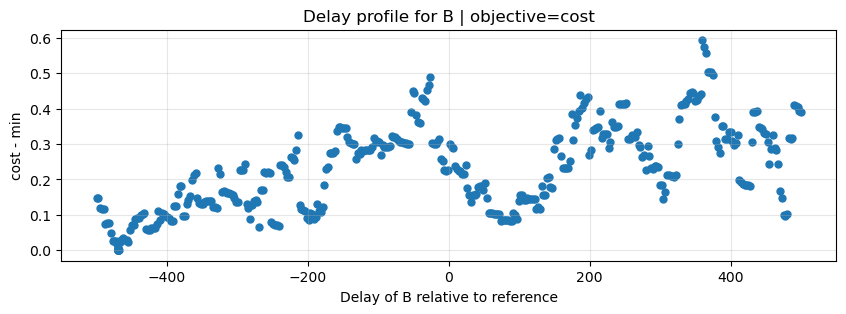

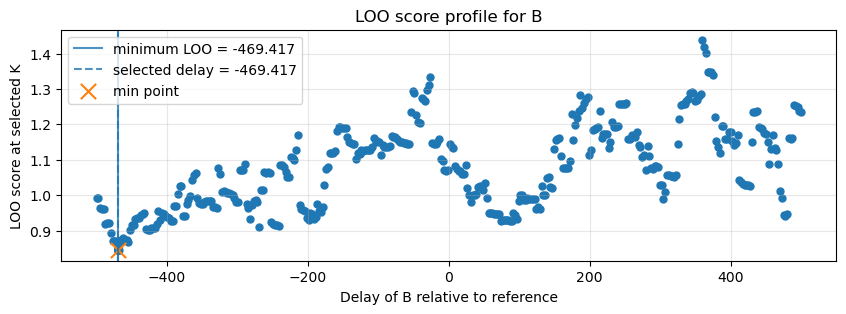


===== LOO PROFILE CHECK FOR B =====
minimum plotted LOO delay: -469.416793733874
minimum plotted LOO value: 0.8444105597155246
selected delay: -469.416793733874
difference selected - min: 0.0



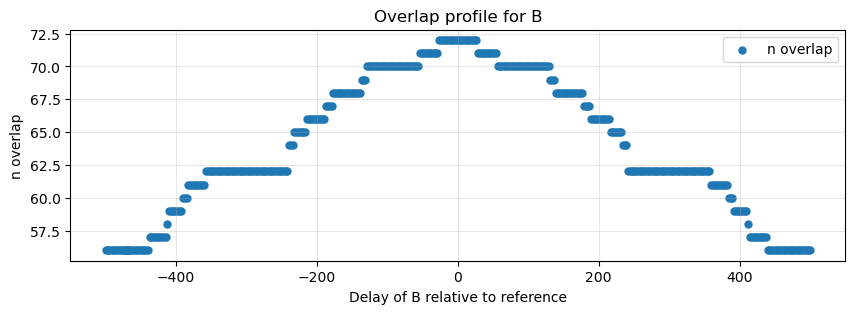

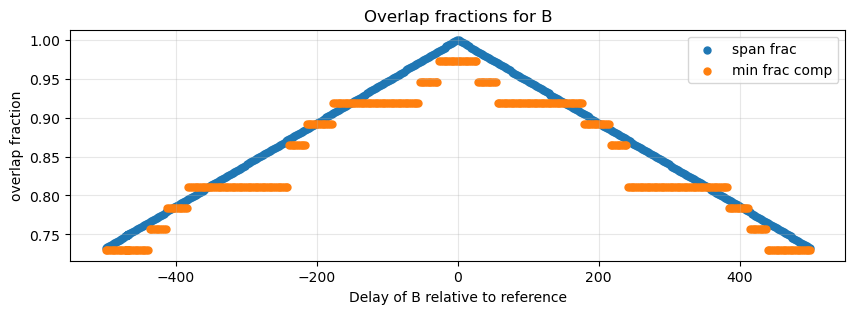

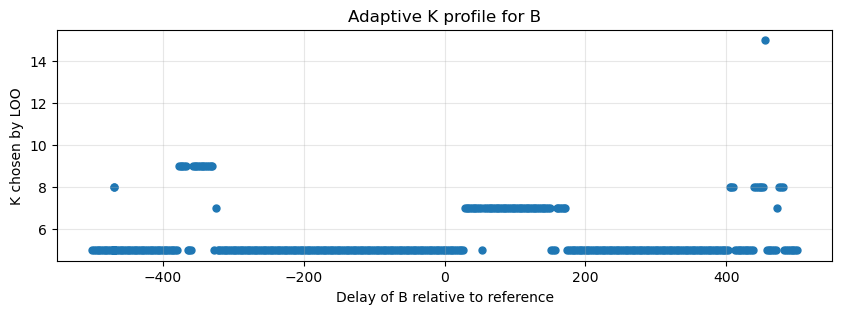

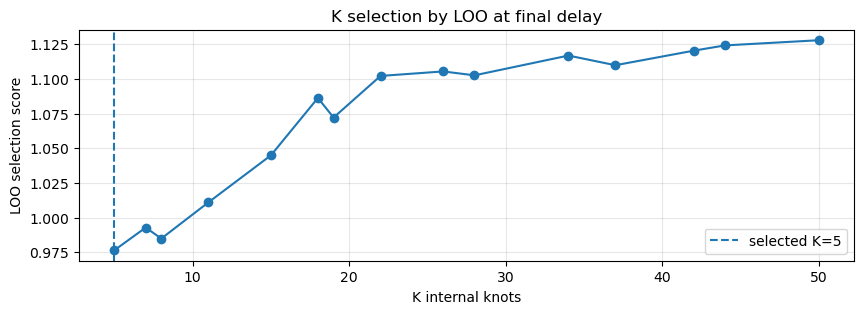

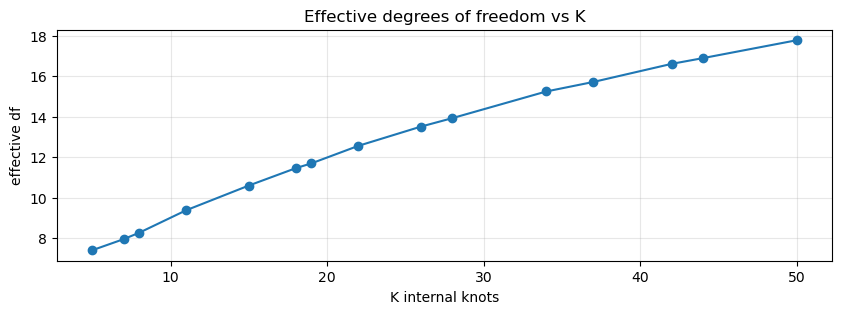

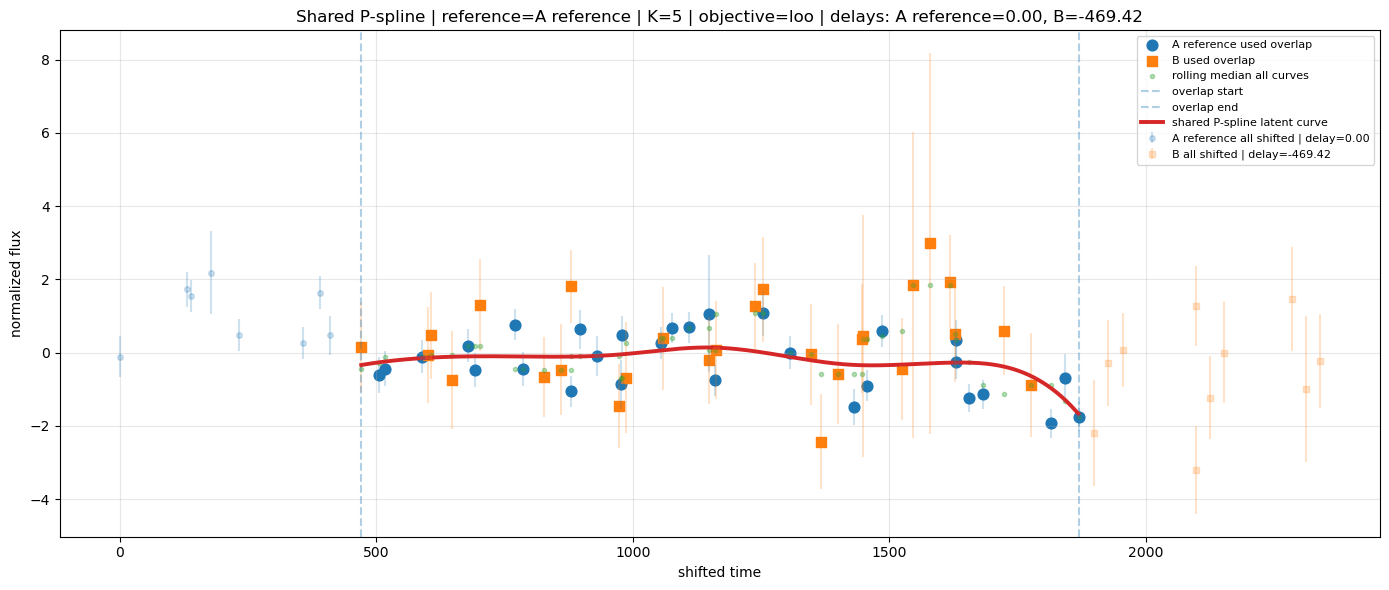

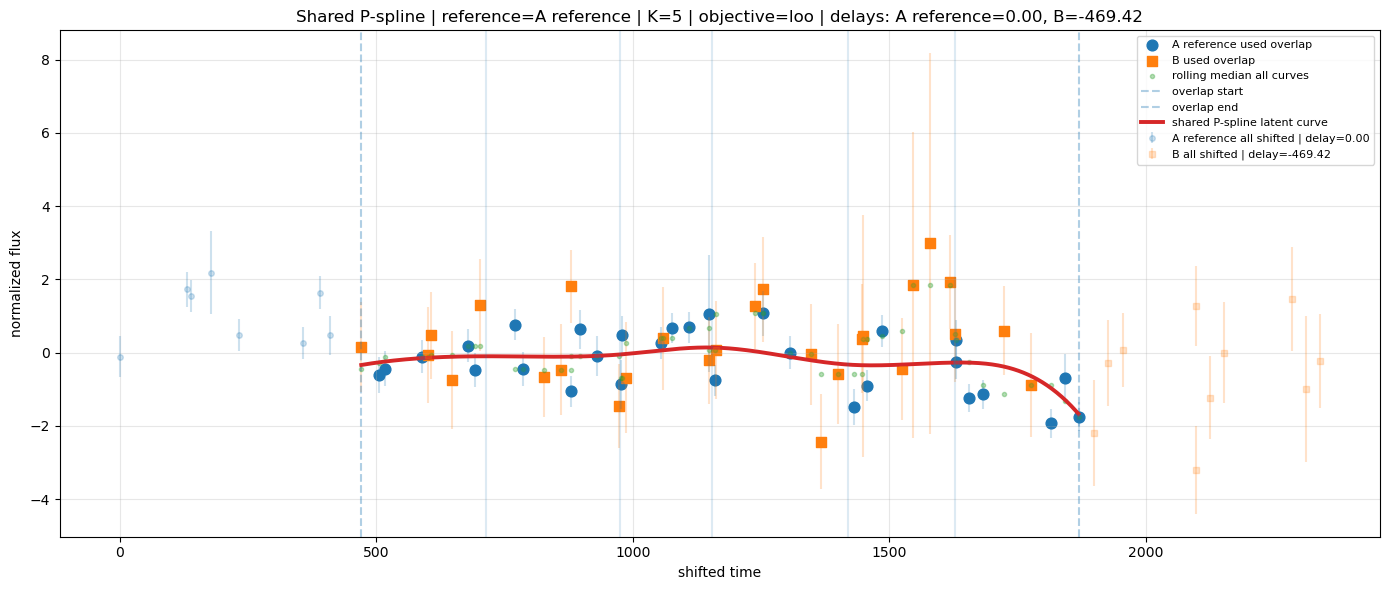

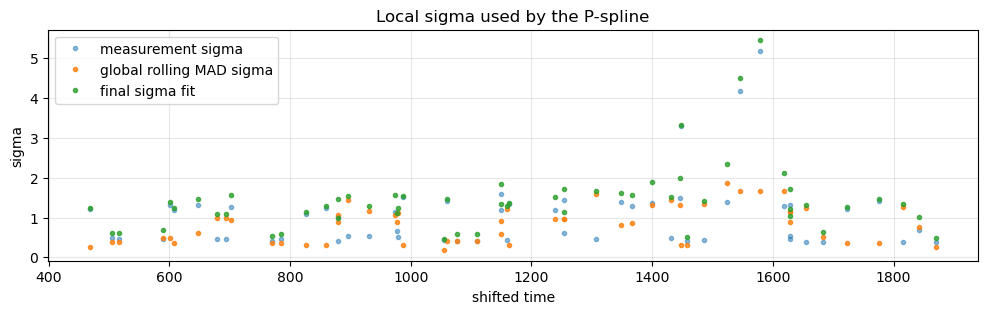

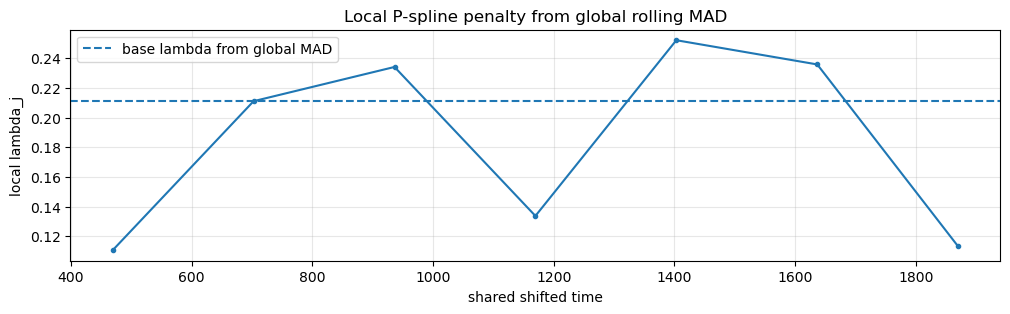

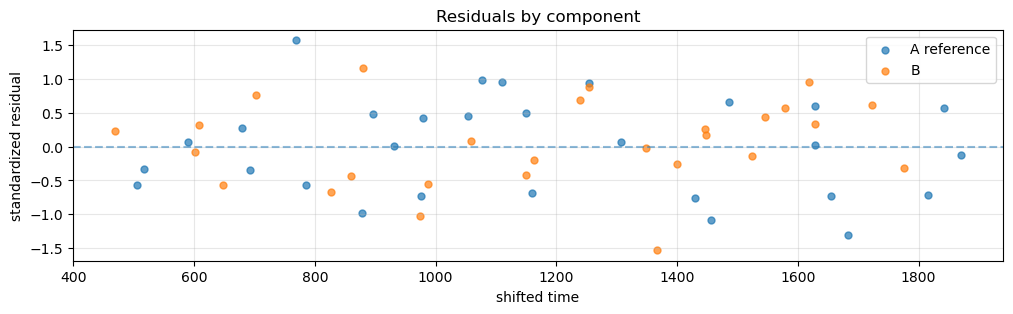

        comp_i            comp_i_id comp_j            comp_j_id  \
0  A reference  5915407711751697345      B  5915407711751697347   

   delay_j_minus_i  
0      -469.416794  
measurement MCMC draw 10/300 | valid=10
measurement MCMC draw 20/300 | valid=20


KeyboardInterrupt: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from functools import lru_cache
from scipy.interpolate import BSpline
from scipy.optimize import minimize_scalar


# ============================================================
# Small tools
# ============================================================

def norm_fit(x):
    x = np.asarray(x, float)

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad

    if not np.isfinite(scale) or scale <= 1e-12:
        scale = np.nanstd(x)

    if not np.isfinite(scale) or scale <= 1e-12:
        scale = 1.0

    return (x - med) / scale, scale


@lru_cache(maxsize=None)
def D2(n):
    """
    Cached second-difference matrix.

    Same matrix as before, but built vectorially and reused for repeated fits
    with the same number of spline coefficients.
    """
    n = int(n)
    q = max(n - 2, 0)
    D = np.zeros((q, n), dtype=float)

    if q > 0:
        i = np.arange(q)
        D[i, i] = 1.0
        D[i, i + 1] = -2.0
        D[i, i + 2] = 1.0

    return D


def safe_solve(A, b):
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0]


def _safe_fill_array(x, default=0.0):
    """
    NumPy-only replacement for the previous pandas interpolate/fillna path.

    It does the same operations:
        - replace +/- inf by NaN,
        - linearly interpolate missing values in both directions,
        - if everything is missing, fill with default.
    """
    x = np.asarray(x, float)

    if len(x) == 0:
        return x

    x = x.copy()
    x[~np.isfinite(x)] = np.nan

    ok = np.isfinite(x)

    if not np.any(ok):
        return np.full_like(x, float(default), dtype=float)

    idx = np.arange(len(x), dtype=float)
    filled = np.interp(idx, idx[ok], x[ok])

    med = np.nanmedian(filled)
    if not np.isfinite(med):
        med = default

    filled[~np.isfinite(filled)] = med
    return filled.astype(float, copy=False)


# ============================================================
# Rolling MAD on all shifted curves together
# ============================================================

def _rolling_window_indices(t, i, window=15, mode="points", time_radius=None):
    if mode == "points":
        window = int(window)

        if window < 3:
            window = 3

        if window % 2 == 0:
            window += 1

        h = window // 2
        lo = max(0, i - h)
        hi = min(len(t), i + h + 1)

        return np.arange(lo, hi)

    if mode == "time":
        if time_radius is None:
            dt = np.diff(np.sort(np.asarray(t, float)))
            dt = dt[np.isfinite(dt) & (dt > 0)]

            if len(dt) == 0:
                time_radius = 1.0
            else:
                time_radius = 0.5 * max(3, int(window)) * float(np.nanmedian(dt))

        return np.where(np.abs(t - t[i]) <= float(time_radius))[0]

    raise ValueError("rolling_mode must be 'points' or 'time'.")


def rolling_median_mad_all_curves(
    t,
    y,
    window=15,
    mode="points",
    time_radius=None,
    min_periods=5,
    mad_floor=0.05,
):
    """
    Rolling median / rolling MAD computed on ALL shifted curves together.

    Same math as the previous version, but faster:
        - no np.arange allocation at every point for points windows,
        - no full np.where scan at every point for time windows,
        - no pandas allocation in the final fill step.
    """

    t = np.asarray(t, float)
    y = np.asarray(y, float)

    if len(t) != len(y):
        raise ValueError("t and y must have the same length.")

    n = len(t)

    if n == 0:
        return {
            "rolling_median_all": np.array([]),
            "sigma_mad_all": np.array([]),
        }

    order = np.argsort(t)
    inv_order = np.empty_like(order)
    inv_order[order] = np.arange(n)

    ts = t[order]
    ys = y[order]

    rolling_median = np.full(n, np.nan)
    sigma_mad = np.full(n, np.nan)

    min_periods = max(1, int(min_periods))

    window = int(window)
    if window < 3:
        window = 3
    if window % 2 == 0:
        window += 1

    def _point_bounds(i, w):
        if w < 3:
            w = 3
        if w % 2 == 0:
            w += 1
        h = w // 2
        return max(0, i - h), min(n, i + h + 1)

    if mode == "time":
        if time_radius is None:
            dt = np.diff(ts)
            dt = dt[np.isfinite(dt) & (dt > 0)]

            if len(dt) == 0:
                time_radius_eff = 1.0
            else:
                time_radius_eff = 0.5 * max(3, int(window)) * float(np.nanmedian(dt))
        else:
            time_radius_eff = float(time_radius)

        left = np.searchsorted(ts, ts - time_radius_eff, side="left")
        right = np.searchsorted(ts, ts + time_radius_eff, side="right")

    elif mode != "points":
        raise ValueError("rolling_mode must be 'points' or 'time'.")

    for i in range(n):
        if mode == "points":
            lo, hi = _point_bounds(i, window)
        else:
            lo, hi = int(left[i]), int(right[i])

        if hi - lo < min_periods:
            lo, hi = _point_bounds(i, max(window, min_periods))

        vals = ys[lo:hi]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        med_i = np.nanmedian(vals)
        rolling_median[i] = med_i
        sigma_mad[i] = 1.4826 * np.nanmedian(np.abs(vals - med_i))

    rolling_median = _safe_fill_array(rolling_median, default=np.nanmedian(ys))
    sigma_mad = _safe_fill_array(sigma_mad, default=mad_floor)
    sigma_mad = np.maximum(sigma_mad, mad_floor)

    return {
        "rolling_median_all": rolling_median[inv_order],
        "sigma_mad_all": sigma_mad[inv_order],
    }


# ============================================================
# K candidates and quantile knots
# ============================================================

def max_valid_K_from_data(t, degree=3):
    t = np.asarray(t, float)
    t = t[np.isfinite(t)]

    n_unique = len(np.unique(t))

    if n_unique <= degree + 3:
        return 0

    return max(0, n_unique - degree - 3)


def auto_K_from_quantiles(
    t,
    degree=3,
    points_per_interval=4,
    K_min=3,
    K_max=50,
):
    """
    Old heuristic K, kept as one possible candidate.
    """

    t = np.asarray(t, float)
    t = t[np.isfinite(t)]

    n = len(np.unique(t))

    if n <= degree + 3:
        return 0

    K_data_max = max_valid_K_from_data(t, degree=degree)
    K_auto = int(np.floor(n / max(points_per_interval, 1)) - 1)

    K_auto = max(K_min, K_auto)
    K_auto = min(K_auto, K_max, K_data_max)

    return int(max(0, K_auto))


def K_candidates_for_LOO(
    t,
    degree=3,
    K_min=3,
    K_max=150,
    K_loo_candidates=None,
    K_loo_n_candidates=15,
    include_old_auto=True,
    points_per_interval=4,
):
    """
    Candidate values for K.
    """

    K_data_max = max_valid_K_from_data(t, degree=degree)
    K_upper = int(min(max(K_max, 0), K_data_max))

    if K_upper <= 0:
        return np.array([0], dtype=int)

    K_lower = int(max(0, min(K_min, K_upper)))

    if K_loo_candidates is not None:
        Ks = np.asarray(K_loo_candidates, dtype=int)
        Ks = Ks[(Ks >= 0) & (Ks <= K_upper)]

        if len(Ks) == 0:
            Ks = np.array([K_lower], dtype=int)

        return np.unique(Ks)

    n_possible = K_upper - K_lower + 1
    n_grid = int(max(2, min(K_loo_n_candidates, n_possible)))

    if n_possible <= n_grid:
        Ks = np.arange(K_lower, K_upper + 1, dtype=int)
    else:
        lin = np.linspace(K_lower, K_upper, n_grid)
        geom = np.geomspace(max(K_lower, 1), max(K_upper, 1), n_grid)

        Ks = np.unique(np.rint(np.r_[lin, geom]).astype(int))
        Ks = Ks[(Ks >= K_lower) & (Ks <= K_upper)]

        if len(Ks) > K_loo_n_candidates:
            idx = np.linspace(0, len(Ks) - 1, K_loo_n_candidates)
            Ks = Ks[np.unique(np.rint(idx).astype(int))]

    if include_old_auto:
        K_old = auto_K_from_quantiles(
            t,
            degree=degree,
            points_per_interval=points_per_interval,
            K_min=K_min,
            K_max=K_max,
        )
        Ks = np.unique(np.r_[Ks, K_old])

    Ks = Ks[(Ks >= 0) & (Ks <= K_upper)]

    if len(Ks) == 0:
        Ks = np.array([K_lower], dtype=int)

    return np.unique(Ks.astype(int))


def quantile_knots(t, K):
    """
    Internal knots placed at empirical quantiles of all shifted overlap times.
    """

    t = np.asarray(t, float)
    t = t[np.isfinite(t)]

    if K <= 0:
        return np.array([])

    q = np.linspace(0, 1, int(K) + 2)[1:-1]
    knots = np.quantile(t, q)

    return np.unique(knots)


# ============================================================
# Lambda from global rolling MAD
# ============================================================

def auto_base_lambda_from_global_mad(
    sigma_mad_all,
    n_basis,
    lambda_scale=10.0,
    lambda_min=0.05,
    lambda_max=1e5,
):
    """
    Global lambda level computed only from global rolling MAD.
    """

    sigma_mad_all = np.asarray(sigma_mad_all, float)
    sigma_mad_all = sigma_mad_all[np.isfinite(sigma_mad_all)]

    if len(sigma_mad_all) == 0:
        med_mad = 0.1
    else:
        med_mad = float(np.nanmedian(sigma_mad_all))

    if not np.isfinite(med_mad) or med_mad <= 0:
        med_mad = 0.1

    base_lambda = lambda_scale * (med_mad ** 2) * max(n_basis, 1)
    base_lambda = float(np.clip(base_lambda, lambda_min, lambda_max))

    return base_lambda


def lambda_vec_from_global_rolling_mad(
    t,
    sigma_mad_all,
    n_basis,
    base_lambda="auto",
    lambda_scale=10.0,
    alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
):
    """
    Local P-spline penalty from rolling MAD computed on all curves together.
    """

    q = n_basis - 2

    if q <= 0:
        return np.array([]), 0.0

    t = np.asarray(t, float)
    sigma_mad_all = np.asarray(sigma_mad_all, float)

    sigma_mad_all = _safe_fill_array(sigma_mad_all, default=mad_floor)
    sigma_mad_all = np.maximum(sigma_mad_all, mad_floor)

    if base_lambda == "auto" or base_lambda is None:
        lambda_base_value = auto_base_lambda_from_global_mad(
            sigma_mad_all=sigma_mad_all,
            n_basis=n_basis,
            lambda_scale=lambda_scale,
        )
    else:
        lambda_base_value = float(base_lambda)

    order = np.argsort(t)
    ts = t[order]
    ms = sigma_mad_all[order]

    penalty_pos = np.linspace(ts.min(), ts.max(), q)
    mad_j = np.interp(penalty_pos, ts, ms)

    ref = np.nanmedian(mad_j)

    if not np.isfinite(ref) or ref <= mad_floor:
        ref = mad_floor

    ratio = mad_j / ref
    raw = lambda_base_value * ratio ** alpha

    med_raw = np.nanmedian(raw)

    if np.isfinite(med_raw) and med_raw > 0:
        lambda_vec = raw * (lambda_base_value / med_raw)
    else:
        lambda_vec = np.full(q, lambda_base_value)

    lambda_vec = np.clip(
        lambda_vec,
        lambda_min_ratio * lambda_base_value,
        lambda_max_ratio * lambda_base_value,
    )

    return lambda_vec, lambda_base_value


# ============================================================
# Data extraction
# ============================================================

def get_curve(g):
    t = pd.to_numeric(g["epoch_obs_jd"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(g["flux_obs"], errors="coerce").to_numpy(float)
    s = pd.to_numeric(g["flux_obs_error"], errors="coerce").to_numpy(float)

    ok = np.isfinite(t) & np.isfinite(y) & np.isfinite(s) & (s > 0)

    t = t[ok]
    y = y[ok]
    s = s[ok]

    idx = np.argsort(t)

    return t[idx], y[idx], s[idx]


def get_components_from_df(df, source_id, comp_ids, names=None):
    """
    Extract 2, 3 or 4 light curves from the dataframe.

    The first component is the reference:
        delay(reference) = 0
    """

    comp_ids = list(comp_ids)

    if len(comp_ids) < 2 or len(comp_ids) > 4:
        raise ValueError("comp_ids must contain 2, 3 or 4 component IDs.")

    if names is None:
        names = [f"comp_{i}" for i in range(len(comp_ids))]

    if len(names) != len(comp_ids):
        raise ValueError("names must have the same length as comp_ids.")

    g = df[df["source_id"] == source_id]

    curves = []

    for cid, name in zip(comp_ids, names):
        cg = g[g["lensComponentSourceId"] == cid]
        t, y, s = get_curve(cg)

        if len(t) == 0:
            raise ValueError(f"No valid data found for component {cid} / {name}")

        curves.append({
            "source_id": source_id,
            "comp_id": cid,
            "name": str(name),
            "t": t,
            "y": y,
            "s": s,
        })

    return {
        "source_id": source_id,
        "comp_ids": comp_ids,
        "names": names,
        "curves": curves,
    }


# ============================================================
# Prepare curves
# ============================================================

def prepare_multicurves(
    curves,
    mad_floor=0.05,
):
    """
    Normalize each curve independently.
    """

    t0 = min(np.asarray(c["t"], float).min() for c in curves)

    prepared = []

    for c in curves:
        t = np.asarray(c["t"], float) - t0
        y_raw = np.asarray(c["y"], float)
        s_raw = np.asarray(c["s"], float)

        y, scale = norm_fit(y_raw)
        s_meas = np.maximum(s_raw / scale, mad_floor)

        prepared.append({
            "source_id": c.get("source_id", None),
            "comp_id": c.get("comp_id", None),
            "name": c.get("name", f"curve_{len(prepared)}"),
            "t": t,
            "y": y,
            "s_meas": s_meas,
            "scale": scale,
            "t0": t0,
        })

    return prepared


# ============================================================
# Delay helpers
# ============================================================

def full_delays_from_free(delay_free):
    delay_free = np.asarray(delay_free, float)
    return np.r_[0.0, delay_free]


def pair_delay_table(names, comp_ids, full_delays):
    rows = []

    for i in range(len(full_delays)):
        for j in range(i + 1, len(full_delays)):
            rows.append({
                "comp_i": names[i],
                "comp_i_id": comp_ids[i],
                "comp_j": names[j],
                "comp_j_id": comp_ids[j],
                "delay_j_minus_i": float(full_delays[j] - full_delays[i]),
            })

    return pd.DataFrame(rows)


# ============================================================
# Overlap data for multiple shifted curves
# ============================================================

def make_shifted_overlap_data_multi(
    curves,
    delay_free,
    min_points=10,
    min_frac=0.75,
    min_span_frac=0.75,
):
    """
    Build common overlap interval after applying delays.

    Convention:
        t_shifted_k = t_k - delay_k

    delay_0 = 0 for the reference component.
    """

    n_comp = len(curves)
    full_delays = full_delays_from_free(delay_free)

    if len(full_delays) != n_comp:
        raise ValueError("delay_free must have length n_components - 1.")

    shifted_t = [
        np.asarray(c["t"], float) - d
        for c, d in zip(curves, full_delays)
    ]

    a = max(t.min() for t in shifted_t)
    b = min(t.max() for t in shifted_t)

    if b <= a:
        return None

    masks = [(t >= a) & (t <= b) for t in shifted_t]

    n_by_comp = np.array([int(m.sum()) for m in masks])
    frac_by_comp = np.array([float(m.mean()) for m in masks])

    if np.any(n_by_comp < min_points):
        return None

    if np.any(frac_by_comp < min_frac):
        return None

    spans = np.array([t.max() - t.min() for t in shifted_t])
    span_ref = max(np.min(spans), 1e-12)
    span_frac = float((b - a) / span_ref)

    if span_frac < min_span_frac:
        return None

    t_all = []
    y_all = []
    s_meas_all = []
    comp_idx_all = []

    for k, (c, t_shift, m) in enumerate(zip(curves, shifted_t, masks)):
        t_all.append(t_shift[m])
        y_all.append(np.asarray(c["y"], float)[m])
        s_meas_all.append(np.asarray(c["s_meas"], float)[m])
        comp_idx_all.append(np.full(int(m.sum()), k, dtype=int))

    t = np.concatenate(t_all)
    y = np.concatenate(y_all)
    s_meas = np.concatenate(s_meas_all)
    comp_idx = np.concatenate(comp_idx_all)

    order = np.argsort(t)

    info = {
        "overlap_start": float(a),
        "overlap_end": float(b),
        "span_frac": span_frac,
        "n_by_comp": n_by_comp,
        "frac_by_comp": frac_by_comp,
    }

    return (
        t[order],
        y[order],
        s_meas[order],
        comp_idx[order],
        info,
    )


# ============================================================
# B-spline basis
# ============================================================

def spline_basis(t, knots, degree=3):
    t = np.asarray(t, float)
    knots = np.sort(np.asarray(knots, float))

    if len(t) == 0:
        raise ValueError("Cannot build a spline basis with empty t.")

    eps = 1e-9 * max(t.max() - t.min(), 1.0)

    kv = np.r_[
        np.repeat(t.min() - eps, degree + 1),
        knots,
        np.repeat(t.max() + eps, degree + 1),
    ]

    # Same B-spline design matrix as the previous one-basis-at-a-time loop,
    # but built directly by SciPy in sparse form then converted to dense.
    try:
        X = BSpline.design_matrix(t, kv, degree, extrapolate=False).toarray()
    except AttributeError:
        # Fallback for old SciPy versions.
        n = len(kv) - degree - 1
        X = np.zeros((len(t), n), dtype=float)

        for i in range(n):
            c = np.zeros(n)
            c[i] = 1.0
            X[:, i] = BSpline(kv, c, degree, extrapolate=False)(t)

    return np.nan_to_num(X), kv


# ============================================================
# Weights and scores
# ============================================================

def balanced_weights_multi(sigma, comp_idx, n_comp):
    """
    Balanced weights:
        - inverse variance weights from local sigma,
        - rebalanced so each component has comparable total weight.

    Same formula as before, but uses np.bincount instead of repeated masks.
    """

    sigma = np.asarray(sigma, float)
    comp_idx = np.asarray(comp_idx, int)

    w = 1.0 / np.maximum(sigma ** 2, 1e-12)
    n = len(w)

    sum_by_comp = np.bincount(comp_idx, weights=w, minlength=n_comp).astype(float)
    scale_by_comp = np.ones(n_comp, dtype=float)

    ok = sum_by_comp > 0
    scale_by_comp[ok] = (n / n_comp) / sum_by_comp[ok]

    w *= scale_by_comp[comp_idx]
    return w


def compute_overlap_cost(
    fit,
    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
):
    span_frac = float(fit.get("span_frac", 1.0))

    if not np.isfinite(span_frac):
        span_frac = 0.0

    span_frac = np.clip(span_frac, 1e-6, 1.0)
    span_loss = max(0.0, min_span_frac_ref - span_frac)

    frac_by_comp = np.asarray(fit.get("frac_by_comp", [1.0]), float)
    frac_by_comp = frac_by_comp[np.isfinite(frac_by_comp)]

    if len(frac_by_comp) == 0:
        min_frac_current = 0.0
    else:
        min_frac_current = float(np.min(frac_by_comp))

    min_frac_current = np.clip(min_frac_current, 1e-6, 1.0)
    frac_loss = max(0.0, min_frac_ref - min_frac_current)

    return float(overlap_penalty) * (span_loss ** 2 + frac_loss ** 2)


def bic_like_score(
    fit,
    df_cap_frac=0.30,
    rough_penalty=1.0,
    overlap_penalty=50.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
):
    n = len(fit["y"])

    if n <= 0:
        return np.inf

    score = fit["chi2"] / n
    score += np.log(n) * fit["df_eff"] / n
    score += rough_penalty * fit["rough"] / max(n, 1)

    score += compute_overlap_cost(
        fit,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
    )

    df_cap = df_cap_frac * n

    if fit["df_eff"] > df_cap:
        score += 1e6 * (fit["df_eff"] - df_cap) ** 2

    return float(score)


def compute_delay_cost(
    fit,
    delay_score="loo",
    df_cap_frac=0.30,
    rough_penalty=1.0,
    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
):
    """
    If delay_score='loo':
        cost = loo_score + overlap_cost
    """

    delay_score = str(delay_score).lower()
    n = len(fit.get("y", []))

    overlap_cost = compute_overlap_cost(
        fit,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
    )

    if delay_score in ["loo", "loocv", "leave-one-out", "leave_one_out"]:
        loo = float(fit.get("loo_score", np.inf))
        return float(loo + overlap_cost)

    if delay_score in ["bic", "bic_like", "corrected_bic"]:
        return bic_like_score(
            fit,
            df_cap_frac=df_cap_frac,
            rough_penalty=rough_penalty,
            overlap_penalty=overlap_penalty,
            min_span_frac_ref=min_span_frac_ref,
            min_frac_ref=min_frac_ref,
        )

    if delay_score in ["chi2", "chi2_per_point"]:
        if n <= 0:
            return np.inf
        return float(fit["chi2"] / n + overlap_cost)

    raise ValueError("delay_score must be 'loo', 'bic' or 'chi2'.")


# ============================================================
# Penalized shared P-spline fit + fast LOO
# ============================================================

def solve_shared_pspline_global_mad_sigma(
    t,
    y,
    sigma_fit,
    sigma_mad_all,
    comp_idx,
    n_comp,
    knots,
    degree=3,
    lambda_base="auto",
    lambda_scale=10.0,
    lambda_alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
    compute_loo=True,
):
    """
    Shared latent curve model:

        y_k(t - delay_k) = shared_spline(t) + offset_k + noise

    Component 0 is reference:
        offset_0 = 0
        delay_0 = 0

    Fast LOO:
        e_LOO_i = e_i / (1 - h_i)

    Optimized without changing the objective:
        - direct SciPy design matrix is used by spline_basis,
        - D2 is cached,
        - R.T @ diag(lambda) @ R avoids explicit diag allocation,
        - coef, df_eff and LOO leverage solve are obtained in one linear solve.
    """

    Xs, kv = spline_basis(t, knots, degree)

    if n_comp > 1:
        Xoff = (comp_idx[:, None] == np.arange(1, n_comp)[None, :]).astype(float)
        X = np.c_[Xs, Xoff]
    else:
        X = Xs

    w = balanced_weights_multi(sigma_fit, comp_idx, n_comp)
    sw = np.sqrt(w)

    Xw = X * sw[:, None]
    yw = y * sw

    n_basis = Xs.shape[1]
    R = D2(n_basis)

    P = np.zeros((X.shape[1], X.shape[1]), dtype=float)

    lambda_vec, lambda_base_value = lambda_vec_from_global_rolling_mad(
        t=t,
        sigma_mad_all=sigma_mad_all,
        n_basis=n_basis,
        base_lambda=lambda_base,
        lambda_scale=lambda_scale,
        alpha=lambda_alpha,
        lambda_min_ratio=lambda_min_ratio,
        lambda_max_ratio=lambda_max_ratio,
        mad_floor=mad_floor,
    )

    if R.shape[0] > 0 and len(lambda_vec) == R.shape[0]:
        # Same as R.T @ np.diag(lambda_vec) @ R, without building diag(lambda_vec).
        P[:n_basis, :n_basis] = (R.T * lambda_vec) @ R

    P += 1e-8 * np.eye(X.shape[1])

    A = Xw.T @ Xw + P
    b = Xw.T @ yw

    # One factorization/solve instead of solving A twice.
    rhs = np.column_stack((b, Xw.T))
    sol = safe_solve(A, rhs)

    coef = sol[:, 0]
    Ainv_XwT = sol[:, 1:]

    pred = X @ coef

    beta = coef[:n_basis]

    offsets = np.zeros(n_comp)

    if n_comp > 1:
        offsets[1:] = coef[n_basis:]

    res_raw = (y - pred) / sigma_fit
    res_bal = sw * (y - pred)

    chi2_balanced = float(np.sum(res_bal ** 2))
    chi2_raw = float(np.sum(res_raw ** 2))

    chi2_by_comp = []
    chi2_mean_by_comp = []
    chi2_bal_by_comp = []
    n_by_comp = []

    for k in range(n_comp):
        m = comp_idx == k

        n_by_comp.append(int(np.sum(m)))
        chi2_by_comp.append(float(np.sum(res_raw[m] ** 2)))

        if np.any(m):
            chi2_mean_by_comp.append(float(np.mean(res_raw[m] ** 2)))
            chi2_bal_by_comp.append(float(np.sum(res_bal[m] ** 2)))
        else:
            chi2_mean_by_comp.append(np.nan)
            chi2_bal_by_comp.append(np.nan)

    if R.shape[0] > 0 and len(lambda_vec) == R.shape[0]:
        d2beta = R @ beta
        rough = float(np.sum(lambda_vec * d2beta ** 2))
    else:
        rough = 0.0

    # Same as trace(Ainv_XwT @ Xw), but avoids building the p x p product.
    df_eff = float(np.sum(Ainv_XwT * Xw.T))

    h_diag = np.full(len(y), np.nan)
    loo_resid = np.full(len(y), np.nan)
    loo_score = np.nan
    loo_score_raw = np.nan
    loo_score_by_comp = [np.nan] * n_comp

    if compute_loo:
        h_diag = np.sum(Ainv_XwT * Xw.T, axis=0)
        h_diag = np.clip(h_diag, -1e6, 1.0 - 1e-8)

        denom = np.maximum(1.0 - h_diag, 1e-8)

        loo_resid_unscaled = (y - pred) / denom

        loo_resid = sw * loo_resid_unscaled
        loo_score = float(np.mean(loo_resid ** 2))

        loo_resid_raw = loo_resid_unscaled / sigma_fit
        loo_score_raw = float(np.mean(loo_resid_raw ** 2))

        loo_score_by_comp = []

        for k in range(n_comp):
            m = comp_idx == k

            if np.any(m):
                loo_score_by_comp.append(float(np.mean(loo_resid[m] ** 2)))
            else:
                loo_score_by_comp.append(np.nan)

    fit = {
        "chi2": chi2_balanced,
        "chi2_raw": chi2_raw,
        "chi2_by_comp": chi2_by_comp,
        "chi2_mean_by_comp": chi2_mean_by_comp,
        "chi2_bal_by_comp": chi2_bal_by_comp,
        "n_by_comp_fit": n_by_comp,
        "rough": rough,
        "df_eff": df_eff,
        "beta": beta,
        "offsets": offsets,
        "pred": pred,
        "res": res_raw,
        "res_balanced": res_bal,
        "kv": kv,
        "knots": knots,
        "t": t,
        "y": y,
        "s": sigma_fit,
        "sigma_fit": sigma_fit,
        "sigma_mad_all": sigma_mad_all,
        "comp_idx": comp_idx,
        "weights": w,
        "hat_diag": h_diag,
        "hat_diag_max": float(np.nanmax(h_diag)) if len(h_diag) else np.nan,
        "loo_resid": loo_resid,
        "loo_score": loo_score,
        "loo_score_raw": loo_score_raw,
        "loo_score_by_comp": loo_score_by_comp,
        "lambda_base": lambda_base_value,
        "lambda_vec": lambda_vec,
        "lambda_vec_min": float(np.nanmin(lambda_vec)) if len(lambda_vec) else np.nan,
        "lambda_vec_max": float(np.nanmax(lambda_vec)) if len(lambda_vec) else np.nan,
        "lambda_vec_median": float(np.nanmedian(lambda_vec)) if len(lambda_vec) else np.nan,
        "lambda_source": "global_rolling_mad_all_curves",
        "sigma_source": "sqrt(sigma_meas^2 + global_rolling_mad_all_curves^2)",
    }

    return fit


# ============================================================
# Adaptive K selection by LOO for one delay vector
# ============================================================

def select_K_by_LOO_for_delay(
    t,
    y,
    sigma_fit,
    sigma_mad_all,
    comp_idx,
    n_comp,
    degree=3,
    points_per_interval=4,
    K_min=3,
    K_max=150,
    K_loo_candidates=None,
    K_loo_n_candidates=15,
    K_loo_complexity_penalty=0.0,
    K_loo_df_cap_frac=0.80,
    lambda_base="auto",
    lambda_scale=10.0,
    lambda_alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
):
    """
    Select K by fast leave-one-out cross-validation.
    """

    Ks = K_candidates_for_LOO(
        t=t,
        degree=degree,
        K_min=K_min,
        K_max=K_max,
        K_loo_candidates=K_loo_candidates,
        K_loo_n_candidates=K_loo_n_candidates,
        include_old_auto=True,
        points_per_interval=points_per_interval,
    )

    records = []
    best_fit = None
    best_score = np.inf
    best_record = None
    n = len(y)

    for K_try in Ks:
        knots = quantile_knots(t, K_try)
        K_eff = len(knots)

        try:
            fit = solve_shared_pspline_global_mad_sigma(
                t=t,
                y=y,
                sigma_fit=sigma_fit,
                sigma_mad_all=sigma_mad_all,
                comp_idx=comp_idx,
                n_comp=n_comp,
                knots=knots,
                degree=degree,
                lambda_base=lambda_base,
                lambda_scale=lambda_scale,
                lambda_alpha=lambda_alpha,
                lambda_min_ratio=lambda_min_ratio,
                lambda_max_ratio=lambda_max_ratio,
                mad_floor=mad_floor,
                compute_loo=True,
            )

            loo = fit.get("loo_score", np.inf)
            df_eff = fit.get("df_eff", np.inf)
            hmax = fit.get("hat_diag_max", np.inf)

            score = loo + K_loo_complexity_penalty * df_eff / max(n, 1)

            if df_eff > K_loo_df_cap_frac * n:
                score = np.inf

            if not np.isfinite(loo):
                score = np.inf

            record = {
                "K": int(K_eff),
                "K_requested": int(K_try),
                "loo_score": float(loo) if np.isfinite(loo) else np.inf,
                "loo_score_raw": float(fit.get("loo_score_raw", np.nan)),
                "loo_selection_score": float(score) if np.isfinite(score) else np.inf,
                "df_eff": float(df_eff) if np.isfinite(df_eff) else np.inf,
                "hat_diag_max": float(hmax) if np.isfinite(hmax) else np.nan,
                "lambda_base": float(fit.get("lambda_base", np.nan)),
                "lambda_median": float(fit.get("lambda_vec_median", np.nan)),
                "valid": bool(np.isfinite(score)),
            }

            records.append(record)

            if score < best_score:
                best_score = score
                best_fit = fit
                best_record = record

        except Exception as e:
            records.append({
                "K": int(K_try),
                "K_requested": int(K_try),
                "loo_score": np.inf,
                "loo_score_raw": np.inf,
                "loo_selection_score": np.inf,
                "df_eff": np.inf,
                "hat_diag_max": np.nan,
                "lambda_base": np.nan,
                "lambda_median": np.nan,
                "valid": False,
                "error": repr(e),
            })

    loo_table = pd.DataFrame(records)

    if best_fit is None:
        K_fallback = auto_K_from_quantiles(
            t=t,
            degree=degree,
            points_per_interval=points_per_interval,
            K_min=K_min,
            K_max=K_max,
        )

        knots = quantile_knots(t, K_fallback)

        best_fit = solve_shared_pspline_global_mad_sigma(
            t=t,
            y=y,
            sigma_fit=sigma_fit,
            sigma_mad_all=sigma_mad_all,
            comp_idx=comp_idx,
            n_comp=n_comp,
            knots=knots,
            degree=degree,
            lambda_base=lambda_base,
            lambda_scale=lambda_scale,
            lambda_alpha=lambda_alpha,
            lambda_min_ratio=lambda_min_ratio,
            lambda_max_ratio=lambda_max_ratio,
            mad_floor=mad_floor,
            compute_loo=True,
        )

        best_record = {
            "K": len(knots),
            "K_requested": int(K_fallback),
            "loo_score": float(best_fit.get("loo_score", np.nan)),
            "loo_score_raw": float(best_fit.get("loo_score_raw", np.nan)),
            "loo_selection_score": float(best_fit.get("loo_score", np.nan)),
            "df_eff": float(best_fit.get("df_eff", np.nan)),
            "hat_diag_max": float(best_fit.get("hat_diag_max", np.nan)),
            "lambda_base": float(best_fit.get("lambda_base", np.nan)),
            "lambda_median": float(best_fit.get("lambda_vec_median", np.nan)),
            "valid": True,
            "fallback": True,
        }

        best_score = best_record["loo_selection_score"]

    best_fit["K_loo_table"] = loo_table
    best_fit["K_loo_best_record"] = best_record
    best_fit["K_selection_score"] = best_score

    return best_fit, loo_table, best_record


# ============================================================
# Fit one delay vector
# ============================================================

def fit_delay_vector_global_mad_sigma(
    curves,
    delay_free,
    degree=3,
    points_per_interval=4,
    K_min=3,
    K_max=150,
    K_selection="loo",
    K_loo_candidates=None,
    K_loo_n_candidates=15,
    K_loo_complexity_penalty=0.0,
    K_loo_df_cap_frac=0.80,
    delay_score="loo",
    rolling_window=15,
    rolling_mode="points",
    rolling_time_radius=None,
    use_global_mad_in_sigma=True,
    lambda_base="auto",
    lambda_scale=10.0,
    lambda_alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
    df_cap_frac=0.30,
    rough_penalty=1.0,
    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
    min_points=10,
    min_frac=0.75,
    min_span_frac=0.75,
):
    data = make_shifted_overlap_data_multi(
        curves,
        delay_free,
        min_points=min_points,
        min_frac=min_frac,
        min_span_frac=min_span_frac,
    )

    if data is None:
        return {"cost": np.inf}

    t, y, s_meas, comp_idx, info = data

    n_comp = len(curves)

    diag_all = rolling_median_mad_all_curves(
        t=t,
        y=y,
        window=rolling_window,
        mode=rolling_mode,
        time_radius=rolling_time_radius,
        min_periods=max(5, rolling_window // 3),
        mad_floor=mad_floor,
    )

    rolling_median_all = diag_all["rolling_median_all"]
    sigma_mad_all = diag_all["sigma_mad_all"]

    if use_global_mad_in_sigma:
        sigma_fit = np.sqrt(s_meas ** 2 + sigma_mad_all ** 2)
    else:
        sigma_fit = s_meas.copy()

    sigma_fit = np.maximum(sigma_fit, mad_floor)

    K_selection = str(K_selection).lower()

    if K_selection in ["loo", "loocv", "leave-one-out", "leave_one_out"]:
        fit, loo_table, best_record = select_K_by_LOO_for_delay(
            t=t,
            y=y,
            sigma_fit=sigma_fit,
            sigma_mad_all=sigma_mad_all,
            comp_idx=comp_idx,
            n_comp=n_comp,
            degree=degree,
            points_per_interval=points_per_interval,
            K_min=K_min,
            K_max=K_max,
            K_loo_candidates=K_loo_candidates,
            K_loo_n_candidates=K_loo_n_candidates,
            K_loo_complexity_penalty=K_loo_complexity_penalty,
            K_loo_df_cap_frac=K_loo_df_cap_frac,
            lambda_base=lambda_base,
            lambda_scale=lambda_scale,
            lambda_alpha=lambda_alpha,
            lambda_min_ratio=lambda_min_ratio,
            lambda_max_ratio=lambda_max_ratio,
            mad_floor=mad_floor,
        )

        K = int(fit["K_loo_best_record"]["K"])
        fit["K_selection"] = "LOO"

    elif K_selection in ["quantile", "auto", "heuristic"]:
        K = auto_K_from_quantiles(
            t,
            degree=degree,
            points_per_interval=points_per_interval,
            K_min=K_min,
            K_max=K_max,
        )

        knots = quantile_knots(t, K)
        K = len(knots)

        fit = solve_shared_pspline_global_mad_sigma(
            t=t,
            y=y,
            sigma_fit=sigma_fit,
            sigma_mad_all=sigma_mad_all,
            comp_idx=comp_idx,
            n_comp=n_comp,
            knots=knots,
            degree=degree,
            lambda_base=lambda_base,
            lambda_scale=lambda_scale,
            lambda_alpha=lambda_alpha,
            lambda_min_ratio=lambda_min_ratio,
            lambda_max_ratio=lambda_max_ratio,
            mad_floor=mad_floor,
            compute_loo=True,
        )

        fit["K_loo_table"] = pd.DataFrame()
        fit["K_loo_best_record"] = None
        fit["K_selection"] = "quantile_heuristic"

    else:
        raise ValueError("K_selection must be 'loo' or 'quantile'.")

    full_delays = full_delays_from_free(delay_free)

    names = [c["name"] for c in curves]
    comp_ids = [c["comp_id"] for c in curves]

    fit["delay_free"] = np.asarray(delay_free, float)
    fit["delays"] = full_delays
    fit["K"] = K
    fit["points_per_interval"] = points_per_interval
    fit["K_max"] = K_max
    fit["delay_score"] = delay_score

    fit["df_cap_frac"] = df_cap_frac
    fit["rough_penalty"] = rough_penalty
    fit["overlap_penalty"] = overlap_penalty
    fit["min_span_frac_ref"] = min_span_frac_ref
    fit["min_frac_ref"] = min_frac_ref

    fit["n_overlap"] = len(t)
    fit["n_by_comp_overlap"] = info["n_by_comp"]
    fit["frac_by_comp"] = info["frac_by_comp"]

    fit["names"] = names
    fit["comp_ids"] = comp_ids
    fit["pair_delays"] = pair_delay_table(names, comp_ids, full_delays)

    fit["s_meas_overlap"] = s_meas
    fit["sigma_fit_overlap"] = sigma_fit
    fit["sigma_mad_all_overlap"] = sigma_mad_all
    fit["rolling_median_all_overlap"] = rolling_median_all

    fit.update(info)

    fit["bic_like"] = bic_like_score(
        fit,
        df_cap_frac=df_cap_frac,
        rough_penalty=rough_penalty,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
    )

    fit["overlap_cost"] = compute_overlap_cost(
        fit,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
    )

    fit["cost"] = compute_delay_cost(
        fit,
        delay_score=delay_score,
        df_cap_frac=df_cap_frac,
        rough_penalty=rough_penalty,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
    )

    fit["df_total"] = fit["df_eff"]

    return fit


# ============================================================
# Coordinate search over delays
# ============================================================

def coordinate_delay_search(
    curves,
    dmin=-700,
    dmax=700,
    ngrid=100,
    degree=3,
    max_passes=3,
    points_per_interval=4,
    K_min=3,
    K_max=150,
    K_selection="loo",
    K_loo_candidates=None,
    K_loo_n_candidates=15,
    K_loo_complexity_penalty=0.0,
    K_loo_df_cap_frac=0.80,
    delay_score="loo",
    rolling_window=15,
    rolling_mode="points",
    rolling_time_radius=None,
    use_global_mad_in_sigma=True,
    lambda_base="auto",
    lambda_scale=10.0,
    lambda_alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
    df_cap_frac=0.30,
    rough_penalty=1.0,
    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
    min_points=10,
    min_frac=0.75,
    min_span_frac=0.75,
    scalar_xatol=0.05,
    force_final_to_min_plotted_loo=True,
    verbose=True,
):
    """
    Coordinate search for 2, 3 or 4 components.

    For N curves:
        free delays = N - 1
    """

    n_comp = len(curves)

    if n_comp < 2 or n_comp > 4:
        raise ValueError("This function supports only 2, 3 or 4 components.")

    D = n_comp - 1
    delay_vec = np.zeros(D, dtype=float)

    profile_rows = []

    grid = np.linspace(dmin, dmax, ngrid)

    def fit_fun(dvec):
        return fit_delay_vector_global_mad_sigma(
            curves=curves,
            delay_free=dvec,
            degree=degree,
            points_per_interval=points_per_interval,
            K_min=K_min,
            K_max=K_max,
            K_selection=K_selection,
            K_loo_candidates=K_loo_candidates,
            K_loo_n_candidates=K_loo_n_candidates,
            K_loo_complexity_penalty=K_loo_complexity_penalty,
            K_loo_df_cap_frac=K_loo_df_cap_frac,
            delay_score=delay_score,
            rolling_window=rolling_window,
            rolling_mode=rolling_mode,
            rolling_time_radius=rolling_time_radius,
            use_global_mad_in_sigma=use_global_mad_in_sigma,
            lambda_base=lambda_base,
            lambda_scale=lambda_scale,
            lambda_alpha=lambda_alpha,
            lambda_min_ratio=lambda_min_ratio,
            lambda_max_ratio=lambda_max_ratio,
            mad_floor=mad_floor,
            df_cap_frac=df_cap_frac,
            rough_penalty=rough_penalty,
            overlap_penalty=overlap_penalty,
            min_span_frac_ref=min_span_frac_ref,
            min_frac_ref=min_frac_ref,
            min_points=min_points,
            min_frac=min_frac,
            min_span_frac=min_span_frac,
        )

    best_fit = fit_fun(delay_vec)
    best_cost = best_fit["cost"]

    if not np.isfinite(best_cost):
        best_cost = np.inf
        best_fit = None

    for p in range(max_passes):
        improved_pass = False

        for dim in range(D):
            component_name = curves[dim + 1]["name"]

            costs = []

            for val in grid:
                candidate = delay_vec.copy()
                candidate[dim] = val

                fit = fit_fun(candidate)
                cost = fit["cost"]

                costs.append(cost)

                profile_rows.append({
                    "pass": p + 1,
                    "dimension": dim,
                    "component": component_name,
                    "delay_value": val,
                    "cost": cost,
                    "delay_score": fit.get("delay_score", None),
                    "loo_score": fit.get("loo_score", np.nan),
                    "bic_like": fit.get("bic_like", np.nan),
                    "overlap_cost": fit.get("overlap_cost", np.nan),
                    "K": fit.get("K", np.nan),
                    "K_selection": fit.get("K_selection", None),
                    "K_loo_selection_score": fit.get("K_selection_score", np.nan),
                    "df_eff": fit.get("df_eff", np.nan),
                    "hat_diag_max": fit.get("hat_diag_max", np.nan),
                    "lambda_base": fit.get("lambda_base", np.nan),
                    "lambda_median": fit.get("lambda_vec_median", np.nan),
                    "sigma_mad_median": np.nanmedian(fit.get("sigma_mad_all_overlap", [np.nan])),
                    "span_frac": fit.get("span_frac", np.nan),
                    "min_frac_comp": np.nanmin(fit.get("frac_by_comp", [np.nan])),
                    "n_overlap": fit.get("n_overlap", np.nan),
                    "stage": "grid",
                })

            costs = np.asarray(costs)
            finite = np.isfinite(costs)

            if not np.any(finite):
                continue

            best_grid_val = grid[np.nanargmin(costs)]
            step = grid[1] - grid[0] if len(grid) > 1 else 1.0

            lo = max(dmin, best_grid_val - 2 * step)
            hi = min(dmax, best_grid_val + 2 * step)

            scalar_records = []

            def scalar_obj(val):
                candidate = delay_vec.copy()
                candidate[dim] = val

                fit = fit_fun(candidate)
                scalar_records.append((val, fit))

                return fit["cost"]

            opt = minimize_scalar(
                scalar_obj,
                bounds=(lo, hi),
                method="bounded",
                options={"xatol": scalar_xatol},
            )

            if opt.success:
                best_val = float(opt.x)
            else:
                best_val = float(best_grid_val)

            candidate = delay_vec.copy()
            candidate[dim] = best_val

            fit = fit_fun(candidate)
            cost = fit["cost"]

            for val, f in scalar_records:
                profile_rows.append({
                    "pass": p + 1,
                    "dimension": dim,
                    "component": component_name,
                    "delay_value": val,
                    "cost": f["cost"],
                    "delay_score": f.get("delay_score", None),
                    "loo_score": f.get("loo_score", np.nan),
                    "bic_like": f.get("bic_like", np.nan),
                    "overlap_cost": f.get("overlap_cost", np.nan),
                    "K": f.get("K", np.nan),
                    "K_selection": f.get("K_selection", None),
                    "K_loo_selection_score": f.get("K_selection_score", np.nan),
                    "df_eff": f.get("df_eff", np.nan),
                    "hat_diag_max": f.get("hat_diag_max", np.nan),
                    "lambda_base": f.get("lambda_base", np.nan),
                    "lambda_median": f.get("lambda_vec_median", np.nan),
                    "sigma_mad_median": np.nanmedian(f.get("sigma_mad_all_overlap", [np.nan])),
                    "span_frac": f.get("span_frac", np.nan),
                    "min_frac_comp": np.nanmin(f.get("frac_by_comp", [np.nan])),
                    "n_overlap": f.get("n_overlap", np.nan),
                    "stage": "scalar",
                })

            profile_rows.append({
                "pass": p + 1,
                "dimension": dim,
                "component": component_name,
                "delay_value": best_val,
                "cost": cost,
                "delay_score": fit.get("delay_score", None),
                "loo_score": fit.get("loo_score", np.nan),
                "bic_like": fit.get("bic_like", np.nan),
                "overlap_cost": fit.get("overlap_cost", np.nan),
                "K": fit.get("K", np.nan),
                "K_selection": fit.get("K_selection", None),
                "K_loo_selection_score": fit.get("K_selection_score", np.nan),
                "df_eff": fit.get("df_eff", np.nan),
                "hat_diag_max": fit.get("hat_diag_max", np.nan),
                "lambda_base": fit.get("lambda_base", np.nan),
                "lambda_median": fit.get("lambda_vec_median", np.nan),
                "sigma_mad_median": np.nanmedian(fit.get("sigma_mad_all_overlap", [np.nan])),
                "span_frac": fit.get("span_frac", np.nan),
                "min_frac_comp": np.nanmin(fit.get("frac_by_comp", [np.nan])),
                "n_overlap": fit.get("n_overlap", np.nan),
                "stage": "best_scalar",
            })

            if cost < best_cost:
                best_cost = cost
                best_fit = fit
                delay_vec = candidate
                improved_pass = True

            if verbose and best_fit is not None:
                print(
                    f"pass={p + 1} | component={component_name} | "
                    f"delay={delay_vec[dim]:.3f} | "
                    f"cost={best_cost:.5f} | "
                    f"LOO={best_fit.get('loo_score', np.nan):.5f} | "
                    f"K={best_fit.get('K', np.nan)} | "
                    f"df={best_fit.get('df_eff', np.nan):.2f} | "
                    f"hmax={best_fit.get('hat_diag_max', np.nan):.3f} | "
                    f"n_overlap={best_fit.get('n_overlap', np.nan)} | "
                    f"span={best_fit.get('span_frac', np.nan):.3f} | "
                    f"min_frac={np.nanmin(best_fit.get('frac_by_comp', [np.nan])):.3f} | "
                    f"sigmaMAD_med={np.nanmedian(best_fit.get('sigma_mad_all_overlap', [np.nan])):.4g} | "
                    f"lambda_med={best_fit.get('lambda_vec_median', np.nan):.4g}"
                )

        if not improved_pass:
            break

    if best_fit is None or not np.isfinite(best_cost):
        raise ValueError(
            "No valid delay solution found. Try reducing min_frac/min_span_frac "
            "or widening dmin/dmax."
        )

    delay_history = pd.DataFrame(profile_rows)

    if (
        force_final_to_min_plotted_loo
        and D == 1
        and str(delay_score).lower() in ["loo", "loocv", "leave-one-out", "leave_one_out"]
    ):
        if len(delay_history) > 0 and "loo_score" in delay_history.columns:
            h = delay_history.copy()
            h = h[np.isfinite(h["loo_score"]) & (h["loo_score"] < 1e299)]

            if len(h) > 0:
                idx_best_loo = h["loo_score"].idxmin()
                best_loo_delay = float(h.loc[idx_best_loo, "delay_value"])
                best_loo_value = float(h.loc[idx_best_loo, "loo_score"])

                refit = fit_fun(np.array([best_loo_delay], dtype=float))

                if np.isfinite(refit.get("loo_score", np.inf)):
                    delay_vec = np.array([best_loo_delay], dtype=float)
                    best_fit = refit
                    best_cost = refit["cost"]

                    best_fit["forced_to_min_plotted_LOO"] = True
                    best_fit["min_plotted_LOO_delay"] = best_loo_delay
                    best_fit["min_plotted_LOO_value"] = best_loo_value

                    if verbose:
                        print()
                        print("===== FORCE FINAL DELAY TO MINIMUM PLOTTED LOO =====")
                        print("selected delay:", best_loo_delay)
                        print("min plotted LOO:", best_loo_value)
                        print("refit LOO:", best_fit.get("loo_score", np.nan))
                        print("final cost:", best_cost)
                        print()

    return {
        "delay": delay_vec[0] if D == 1 else None,
        "delay_free": delay_vec,
        "delays": full_delays_from_free(delay_vec),
        "fit": best_fit,
        "curves": curves,
        "delay_history": delay_history,
        "pair_delays": best_fit["pair_delays"],
        "cost": best_cost,
    }


# ============================================================
# Main estimator
# ============================================================

def estimate_delay_multi_globalRollingMADsigma(
    curves,
    dmin=-700,
    dmax=700,
    ngrid=100,
    degree=3,
    max_delay_passes=3,
    points_per_interval=4,
    K_min=3,
    K_max=150,
    K_selection="loo",
    K_loo_candidates=None,
    K_loo_n_candidates=15,
    K_loo_complexity_penalty=0.0,
    K_loo_df_cap_frac=0.80,
    delay_score="loo",
    rolling_window=15,
    rolling_mode="points",
    rolling_time_radius=None,
    use_global_mad_in_sigma=True,
    lambda_base="auto",
    lambda_scale=10.0,
    lambda_alpha=1.0,
    lambda_min_ratio=0.1,
    lambda_max_ratio=10.0,
    mad_floor=0.05,
    df_cap_frac=0.30,
    rough_penalty=1.0,
    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,
    min_points=10,
    min_frac=0.75,
    min_span_frac=0.75,
    scalar_xatol=0.05,
    force_final_to_min_plotted_loo=True,
    verbose=True,
):
    """
    Complete estimator.

    K:
        adaptive by fast LOO for each delay candidate.

    Delay objective:
        if delay_score='loo', the selected delay is the minimum of the LOO profile.
    """

    prepared_curves = prepare_multicurves(
        curves=curves,
        mad_floor=mad_floor,
    )

    res = coordinate_delay_search(
        curves=prepared_curves,
        dmin=dmin,
        dmax=dmax,
        ngrid=ngrid,
        degree=degree,
        max_passes=max_delay_passes,
        points_per_interval=points_per_interval,
        K_min=K_min,
        K_max=K_max,
        K_selection=K_selection,
        K_loo_candidates=K_loo_candidates,
        K_loo_n_candidates=K_loo_n_candidates,
        K_loo_complexity_penalty=K_loo_complexity_penalty,
        K_loo_df_cap_frac=K_loo_df_cap_frac,
        delay_score=delay_score,
        rolling_window=rolling_window,
        rolling_mode=rolling_mode,
        rolling_time_radius=rolling_time_radius,
        use_global_mad_in_sigma=use_global_mad_in_sigma,
        lambda_base=lambda_base,
        lambda_scale=lambda_scale,
        lambda_alpha=lambda_alpha,
        lambda_min_ratio=lambda_min_ratio,
        lambda_max_ratio=lambda_max_ratio,
        mad_floor=mad_floor,
        df_cap_frac=df_cap_frac,
        rough_penalty=rough_penalty,
        overlap_penalty=overlap_penalty,
        min_span_frac_ref=min_span_frac_ref,
        min_frac_ref=min_frac_ref,
        min_points=min_points,
        min_frac=min_frac,
        min_span_frac=min_span_frac,
        scalar_xatol=scalar_xatol,
        force_final_to_min_plotted_loo=force_final_to_min_plotted_loo,
        verbose=verbose,
    )

    return res


# ============================================================
# Plots
# ============================================================

def plot_delay_profiles_multi(res, y_col="cost"):
    h = res.get("delay_history", None)

    if h is None or len(h) == 0:
        print("No delay profile available.")
        return

    h = h[np.isfinite(h[y_col]) & (h[y_col] < 1e299)].copy()

    if len(h) == 0:
        print(f"No finite {y_col} profile available.")
        return

    for component in h["component"].dropna().unique():
        g = h[h["component"] == component]

        plt.figure(figsize=(10, 3))
        plt.scatter(g["delay_value"], g[y_col] - g[y_col].min(), s=25)

        plt.xlabel(f"Delay of {component} relative to reference")
        plt.ylabel(f"{y_col} - min")
        plt.title(f"Delay profile for {component} | objective={y_col}")
        plt.grid(alpha=0.3)
        plt.show()


def plot_LOO_score_profile(res):
    h = res.get("delay_history", None)

    if h is None or len(h) == 0:
        print("No delay profile available.")
        return

    h = h[np.isfinite(h["loo_score"]) & (h["loo_score"] < 1e299)].copy()

    if len(h) == 0:
        print("No finite LOO score available.")
        return

    for component in h["component"].dropna().unique():
        g = h[h["component"] == component].copy()

        if len(g) == 0:
            continue

        idx_min = g["loo_score"].idxmin()
        min_delay = float(g.loc[idx_min, "delay_value"])
        min_loo = float(g.loc[idx_min, "loo_score"])

        dim = int(g["dimension"].iloc[0])
        selected_delay = float(res["delay_free"][dim])

        plt.figure(figsize=(10, 3))
        plt.scatter(g["delay_value"], g["loo_score"], s=25)

        plt.axvline(
            min_delay,
            ls="-",
            alpha=0.8,
            label=f"minimum LOO = {min_delay:.3f}",
        )

        plt.axvline(
            selected_delay,
            ls="--",
            alpha=0.8,
            label=f"selected delay = {selected_delay:.3f}",
        )

        plt.scatter(
            [min_delay],
            [min_loo],
            s=120,
            marker="x",
            label="min point",
        )

        plt.xlabel(f"Delay of {component} relative to reference")
        plt.ylabel("LOO score at selected K")
        plt.title(f"LOO score profile for {component}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

        print()
        print(f"===== LOO PROFILE CHECK FOR {component} =====")
        print("minimum plotted LOO delay:", min_delay)
        print("minimum plotted LOO value:", min_loo)
        print("selected delay:", selected_delay)
        print("difference selected - min:", selected_delay - min_delay)
        print()


def plot_overlap_profile(res):
    h = res.get("delay_history", None)

    if h is None or len(h) == 0:
        print("No delay profile available.")
        return

    h = h[np.isfinite(h["cost"]) & (h["cost"] < 1e299)].copy()

    if len(h) == 0:
        print("No finite delay profile available.")
        return

    for component in h["component"].dropna().unique():
        g = h[h["component"] == component]

        plt.figure(figsize=(10, 3))
        plt.scatter(g["delay_value"], g["n_overlap"], s=25, label="n overlap")
        plt.xlabel(f"Delay of {component} relative to reference")
        plt.ylabel("n overlap")
        plt.title(f"Overlap profile for {component}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 3))
        plt.scatter(g["delay_value"], g["span_frac"], s=25, label="span frac")
        plt.scatter(g["delay_value"], g["min_frac_comp"], s=25, label="min frac comp")
        plt.xlabel(f"Delay of {component} relative to reference")
        plt.ylabel("overlap fraction")
        plt.title(f"Overlap fractions for {component}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


def plot_K_profile(res):
    h = res.get("delay_history", None)

    if h is None or len(h) == 0:
        print("No delay profile available.")
        return

    h = h[np.isfinite(h["cost"]) & (h["cost"] < 1e299)].copy()

    if len(h) == 0:
        print("No finite delay profile available.")
        return

    for component in h["component"].dropna().unique():
        g = h[h["component"] == component]

        plt.figure(figsize=(10, 3))
        plt.scatter(g["delay_value"], g["K"], s=25)
        plt.xlabel(f"Delay of {component} relative to reference")
        plt.ylabel("K chosen by LOO")
        plt.title(f"Adaptive K profile for {component}")
        plt.grid(alpha=0.3)
        plt.show()


def plot_K_loo_table(res):
    fit = res["fit"]
    tab = fit.get("K_loo_table", None)

    if tab is None or len(tab) == 0:
        print("No K LOO table available. Use K_selection='loo'.")
        return

    tab = tab[np.isfinite(tab["loo_selection_score"])].copy()

    if len(tab) == 0:
        print("No finite K LOO score available.")
        return

    plt.figure(figsize=(10, 3))
    plt.plot(tab["K"], tab["loo_selection_score"], "o-")
    plt.axvline(fit["K"], ls="--", label=f"selected K={fit['K']}")
    plt.xlabel("K internal knots")
    plt.ylabel("LOO selection score")
    plt.title("K selection by LOO at final delay")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(tab["K"], tab["df_eff"], "o-")
    plt.xlabel("K internal knots")
    plt.ylabel("effective df")
    plt.title("Effective degrees of freedom vs K")
    plt.grid(alpha=0.3)
    plt.show()


def plot_fit_multi(res, degree=3, show_knots=False, title=None):
    fit = res["fit"]
    curves = res["curves"]
    delays = np.asarray(res["delays"], float)

    names = fit["names"]

    shifted_times = [
        np.asarray(c["t"], float) - d
        for c, d in zip(curves, delays)
    ]

    xmin = min(t.min() for t in shifted_times)
    xmax = max(t.max() for t in shifted_times)

    x = np.linspace(xmin, xmax, 1000)
    S = BSpline(fit["kv"], fit["beta"], degree, extrapolate=False)(x)

    markers = ["o", "s", "^", "D"]

    plt.figure(figsize=(14, 6))

    for k, (c, t_shift, name, d) in enumerate(zip(curves, shifted_times, names, delays)):
        marker = markers[k % len(markers)]

        plt.errorbar(
            t_shift,
            c["y"],
            yerr=c["s_meas"],
            fmt=marker,
            ms=4,
            alpha=0.22,
            capsize=0,
            label=f"{name} all shifted | delay={d:.2f}",
        )

    comp_idx = fit["comp_idx"]

    for k, name in enumerate(names):
        marker = markers[k % len(markers)]
        m = comp_idx == k

        plt.scatter(
            fit["t"][m],
            fit["y"][m],
            s=60,
            marker=marker,
            label=f"{name} used overlap",
        )

    plt.plot(
        fit["t"],
        fit["rolling_median_all_overlap"],
        ".",
        alpha=0.35,
        label="rolling median all curves",
    )

    plt.axvline(fit["overlap_start"], ls="--", alpha=0.35, label="overlap start")
    plt.axvline(fit["overlap_end"], ls="--", alpha=0.35, label="overlap end")

    plt.plot(x, S, lw=2.8, label="shared P-spline latent curve")

    if show_knots:
        for kk in fit["knots"]:
            plt.axvline(kk, alpha=0.15)

    plt.xlabel("shifted time")
    plt.ylabel("normalized flux")

    if title is None:
        ref = names[0]
        delay_text = ", ".join(
            f"{names[k]}={delays[k]:.2f}"
            for k in range(len(names))
        )
        title = (
            f"Shared P-spline | reference={ref} | "
            f"K={fit['K']} | objective={fit.get('delay_score', '?')} | delays: {delay_text}"
        )

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_global_mad_sigma_diagnostics(res):
    fit = res["fit"]

    plt.figure(figsize=(12, 3))
    plt.plot(fit["t"], fit["s_meas_overlap"], "o", ms=3, alpha=0.5, label="measurement sigma")
    plt.plot(fit["t"], fit["sigma_mad_all_overlap"], "o", ms=3, alpha=0.8, label="global rolling MAD sigma")
    plt.plot(fit["t"], fit["sigma_fit_overlap"], "o", ms=3, alpha=0.8, label="final sigma fit")
    plt.xlabel("shifted time")
    plt.ylabel("sigma")
    plt.title("Local sigma used by the P-spline")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    lambda_vec = fit.get("lambda_vec", None)

    if lambda_vec is not None and len(lambda_vec) > 0:
        x = np.linspace(fit["t"].min(), fit["t"].max(), len(lambda_vec))

        plt.figure(figsize=(12, 3))
        plt.plot(x, lambda_vec, "o-", ms=3)
        plt.axhline(fit["lambda_base"], ls="--", label="base lambda from global MAD")
        plt.xlabel("shared shifted time")
        plt.ylabel("local lambda_j")
        plt.title("Local P-spline penalty from global rolling MAD")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


def plot_residuals_multi(res):
    fit = res["fit"]
    names = fit["names"]
    comp_idx = fit["comp_idx"]

    plt.figure(figsize=(12, 3))

    for k, name in enumerate(names):
        m = comp_idx == k
        plt.scatter(fit["t"][m], fit["res"][m], s=25, alpha=0.7, label=name)

    plt.axhline(0, ls="--", alpha=0.5)
    plt.xlabel("shifted time")
    plt.ylabel("standardized residual")
    plt.title("Residuals by component")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


# ============================================================
# Print results
# ============================================================

def print_result_multi(system, res):
    fit = res["fit"]

    print("source_id:", system.get("source_id", None))
    print("reference:", fit["names"][0], "| comp_id:", fit["comp_ids"][0])
    print()

    print("===== DELAYS RELATIVE TO REFERENCE =====")

    for name, cid, d in zip(fit["names"], fit["comp_ids"], res["delays"]):
        print(f"{name:>20s} | comp_id={cid} | delay={d:.4f}")

    print()
    print("===== PAIR DELAYS =====")
    print(res["pair_delays"].to_string(index=False))

    print()
    print("===== DELAY OBJECTIVE =====")
    print("delay_score used by search:", fit.get("delay_score", None))
    print("final cost minimized:", fit["cost"])
    print("LOO score:", fit.get("loo_score", np.nan))
    print("bic_like:", fit.get("bic_like", np.nan))
    print("overlap_cost:", fit.get("overlap_cost", np.nan))
    print("forced_to_min_plotted_LOO:", fit.get("forced_to_min_plotted_LOO", False))
    print("min_plotted_LOO_delay:", fit.get("min_plotted_LOO_delay", np.nan))
    print("min_plotted_LOO_value:", fit.get("min_plotted_LOO_value", np.nan))

    print()
    print("===== FIT QUALITY =====")
    print("chi2 balanced:", fit["chi2"])
    print("chi2 raw:", fit["chi2_raw"])
    print("chi2 per point:", fit["chi2"] / max(fit["n_overlap"], 1))

    print()
    print("chi2 mean by component:")

    for name, chi in zip(fit["names"], fit["chi2_mean_by_comp"]):
        print(f"{name:>20s}: {chi:.4f}")

    print()
    print("df_eff:", fit["df_eff"])
    print("df_total:", fit["df_total"])
    print("rough:", fit["rough"])

    print()
    print("===== ADAPTIVE K BY LOO =====")
    print("K selection:", fit.get("K_selection", None))
    print("K selected:", fit["K"])
    print("K max allowed:", fit.get("K_max", "see call"))
    print("LOO score at selected K:", fit.get("loo_score", np.nan))
    print("LOO score raw:", fit.get("loo_score_raw", np.nan))
    print("max hat diag:", fit.get("hat_diag_max", np.nan))

    best = fit.get("K_loo_best_record", None)

    if best is not None:
        print("best K LOO record:", best)

    tab = fit.get("K_loo_table", None)

    if tab is not None and len(tab) > 0:
        print()
        print("K LOO table at final delay:")

        cols = [
            "K",
            "loo_score",
            "loo_selection_score",
            "df_eff",
            "hat_diag_max",
            "lambda_base",
            "lambda_median",
            "valid",
        ]

        cols = [c for c in cols if c in tab.columns]

        print(tab[cols].to_string(index=False))

    print()
    print("===== LOCAL SIGMA / LOCAL LAMBDA =====")
    print("sigma source:", fit["sigma_source"])
    print("sigma meas median:", float(np.nanmedian(fit["s_meas_overlap"])))
    print("sigma MAD all median:", float(np.nanmedian(fit["sigma_mad_all_overlap"])))
    print("sigma fit median:", float(np.nanmedian(fit["sigma_fit_overlap"])))
    print("lambda source:", fit["lambda_source"])
    print("lambda base:", fit["lambda_base"])
    print("lambda_vec min:", fit["lambda_vec_min"])
    print("lambda_vec median:", fit["lambda_vec_median"])
    print("lambda_vec max:", fit["lambda_vec_max"])

    print()
    print("===== OVERLAP =====")
    print("n overlap:", fit["n_overlap"])

    for name, n, frac in zip(fit["names"], fit["n_by_comp_overlap"], fit["frac_by_comp"]):
        print(f"{name:>20s}: n={int(n)} | frac={frac:.3f}")

    print("span frac:", fit["span_frac"])
    print("overlap start:", fit["overlap_start"])
    print("overlap end:", fit["overlap_end"])


# ============================================================
# Measurement-error Monte Carlo uncertainty
# ============================================================

def clone_system_with_fluxobs_error_draw(system, rng, error_scale=1.0):
    """
    Draw one noisy realization of the light curves using the measurement errors.

    For each observed point:
        flux_obs_draw = flux_obs + Normal(0, error_scale * flux_obs_error)

    This is done BEFORE normalization, so the uncertainty of flux_obs_error is
    propagated through the whole estimator.
    """

    new_curves = []

    for c in system["curves"]:
        t = np.asarray(c["t"], float).copy()
        y = np.asarray(c["y"], float).copy()
        s = np.asarray(c["s"], float).copy()

        ok = np.isfinite(y) & np.isfinite(s) & (s > 0)

        noise = np.zeros_like(y, dtype=float)
        noise[ok] = rng.normal(
            loc=0.0,
            scale=float(error_scale) * s[ok],
        )

        c_new = dict(c)
        c_new["t"] = t
        c_new["y"] = y + noise
        c_new["s"] = s
        c_new["measurement_noise_draw"] = noise

        new_curves.append(c_new)

    return {
        "source_id": system.get("source_id", None),
        "comp_ids": list(system.get("comp_ids", [c.get("comp_id", None) for c in new_curves])),
        "names": list(system.get("names", [c.get("name", f"comp_{i}") for i, c in enumerate(new_curves)])),
        "curves": new_curves,
    }


def _summarize_1d_samples(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return {
            "n_valid": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "q02_5": np.nan,
            "q16": np.nan,
            "q84": np.nan,
            "q97_5": np.nan,
            "err_minus_16_84": np.nan,
            "err_plus_16_84": np.nan,
            "err_minus_95": np.nan,
            "err_plus_95": np.nan,
        }

    q02_5, q16, q50, q84, q97_5 = np.percentile(
        x,
        [2.5, 16, 50, 84, 97.5],
    )

    return {
        "n_valid": int(len(x)),
        "mean": float(np.mean(x)),
        "median": float(q50),
        "std": float(np.std(x, ddof=1)) if len(x) > 1 else 0.0,
        "q02_5": float(q02_5),
        "q16": float(q16),
        "q84": float(q84),
        "q97_5": float(q97_5),
        "err_minus_16_84": float(q50 - q16),
        "err_plus_16_84": float(q84 - q50),
        "err_minus_95": float(q50 - q02_5),
        "err_plus_95": float(q97_5 - q50),
    }


def summarize_delay_samples(delay_samples, names=None, comp_ids=None):
    """
    Summary of sampled delays.

    delay_samples shape:
        (n_samples, n_components)

    Column 0 is the reference component delay and should be 0.
    """

    delay_samples = np.asarray(delay_samples, float)

    if delay_samples.ndim != 2:
        raise ValueError("delay_samples must be a 2D array: n_samples x n_components")

    n_comp = delay_samples.shape[1]

    if names is None:
        names = [f"comp_{i}" for i in range(n_comp)]

    if comp_ids is None:
        comp_ids = [None] * n_comp

    rows_abs = []

    for k in range(n_comp):
        s = _summarize_1d_samples(delay_samples[:, k])
        s.update({
            "component": names[k],
            "comp_id": comp_ids[k],
            "delay_definition": f"delay({names[k]}) relative to reference {names[0]}",
        })
        rows_abs.append(s)

    rows_pair = []

    for i in range(n_comp):
        for j in range(i + 1, n_comp):
            x = delay_samples[:, j] - delay_samples[:, i]
            s = _summarize_1d_samples(x)
            s.update({
                "comp_i": names[i],
                "comp_i_id": comp_ids[i],
                "comp_j": names[j],
                "comp_j_id": comp_ids[j],
                "delay_definition": f"delay({names[j]}) - delay({names[i]})",
            })
            rows_pair.append(s)

    abs_summary = pd.DataFrame(rows_abs)
    pair_summary = pd.DataFrame(rows_pair)

    first_cols_abs = [
        "component",
        "comp_id",
        "delay_definition",
        "n_valid",
    ]

    other_cols_abs = [
        c for c in abs_summary.columns
        if c not in first_cols_abs
    ]

    abs_summary = abs_summary[first_cols_abs + other_cols_abs]

    first_cols_pair = [
        "comp_i",
        "comp_i_id",
        "comp_j",
        "comp_j_id",
        "delay_definition",
        "n_valid",
    ]

    other_cols_pair = [
        c for c in pair_summary.columns
        if c not in first_cols_pair
    ]

    pair_summary = pair_summary[first_cols_pair + other_cols_pair]

    return abs_summary, pair_summary


def run_fluxobs_error_mcmc_uncertainty(
    system,
    estimator_kwargs,
    n_samples=200,
    random_seed=123,
    error_scale=1.0,
    base_res=None,
    force_same_K_as_base=True,
    progress_every=10,
    verbose=True,
):
    """
    Propagate measurement uncertainty from flux_obs_error to the time delay.

    IMPORTANT:
    This does NOT sample an artificial posterior directly on the delay.
    It samples the observed fluxes using the real measurement uncertainty:

        flux_obs_i^(m) = flux_obs_i + Normal(0, error_scale * flux_obs_error_i)

    Then for every sampled light curve, it reruns the full delay estimator.

    Parameters
    ----------
    system : dict
        Output of get_components_from_df(...). Must contain raw y=flux_obs
        and s=flux_obs_error.

    estimator_kwargs : dict
        Same keyword arguments you pass to estimate_delay_multi_globalRollingMADsigma.

    n_samples : int
        Number of Monte Carlo measurement draws.

    error_scale : float
        1.0 means use flux_obs_error as provided.
        2.0 would double the measurement uncertainty.

    base_res : dict or None
        Result on the original data. If None, it is computed first.

    force_same_K_as_base : bool
        If True, MCMC keeps the final K selected on the real data.
        This is much faster and isolates the uncertainty due to flux_obs_error.
        If False, K is reselected by LOO at every draw, but it can be very slow.
    """

    rng = np.random.default_rng(random_seed)

    estimator_kwargs = dict(estimator_kwargs)
    estimator_kwargs.setdefault("verbose", False)

    if base_res is None:
        if verbose:
            print("Running base fit on original data...")

        base_res = estimate_delay_multi_globalRollingMADsigma(
            system["curves"],
            **estimator_kwargs,
        )

    mcmc_kwargs = dict(estimator_kwargs)
    mcmc_kwargs["verbose"] = False

    if force_same_K_as_base:
        K_base = int(base_res["fit"]["K"])

        mcmc_kwargs["K_selection"] = "loo"
        mcmc_kwargs["K_loo_candidates"] = [K_base]
        mcmc_kwargs["K_loo_n_candidates"] = 1
        mcmc_kwargs["K_min"] = min(int(mcmc_kwargs.get("K_min", K_base)), K_base)
        mcmc_kwargs["K_max"] = max(int(mcmc_kwargs.get("K_max", K_base)), K_base)

    n_comp = len(system["curves"])

    names = list(system.get(
        "names",
        [c.get("name", f"comp_{i}") for i, c in enumerate(system["curves"])],
    ))

    comp_ids = list(system.get(
        "comp_ids",
        [c.get("comp_id", None) for c in system["curves"]],
    ))

    sample_rows = []
    delay_samples = []
    delay_free_samples = []

    for m in range(int(n_samples)):
        draw_system = clone_system_with_fluxobs_error_draw(
            system=system,
            rng=rng,
            error_scale=error_scale,
        )

        row = {
            "sample": m,
            "valid": False,
            "cost": np.nan,
            "loo_score": np.nan,
            "bic_like": np.nan,
            "K": np.nan,
            "df_eff": np.nan,
            "n_overlap": np.nan,
            "error": None,
        }

        try:
            res_m = estimate_delay_multi_globalRollingMADsigma(
                draw_system["curves"],
                **mcmc_kwargs,
            )

            delays = np.asarray(res_m["delays"], float)
            delay_free = np.asarray(res_m["delay_free"], float)

            if len(delays) != n_comp:
                raise ValueError("Unexpected number of delays returned.")

            row.update({
                "valid": True,
                "cost": float(res_m.get("cost", np.nan)),
                "loo_score": float(res_m["fit"].get("loo_score", np.nan)),
                "bic_like": float(res_m["fit"].get("bic_like", np.nan)),
                "K": int(res_m["fit"].get("K", -1)),
                "df_eff": float(res_m["fit"].get("df_eff", np.nan)),
                "n_overlap": int(res_m["fit"].get("n_overlap", -1)),
            })

            for k, name in enumerate(names):
                row[f"delay_{name}"] = float(delays[k])

            for i in range(n_comp):
                for j in range(i + 1, n_comp):
                    row[f"pair_delay_{names[j]}_minus_{names[i]}"] = float(
                        delays[j] - delays[i]
                    )

            delay_samples.append(delays)
            delay_free_samples.append(delay_free)

        except Exception as e:
            row["error"] = repr(e)

        sample_rows.append(row)

        if verbose and progress_every is not None and progress_every > 0:
            if (m + 1) % int(progress_every) == 0 or (m + 1) == int(n_samples):
                n_valid = int(sum(r["valid"] for r in sample_rows))
                print(f"measurement MCMC draw {m + 1}/{n_samples} | valid={n_valid}")

    samples = pd.DataFrame(sample_rows)

    if len(delay_samples) > 0:
        delay_samples_arr = np.vstack(delay_samples)
        delay_free_samples_arr = np.vstack(delay_free_samples)
    else:
        delay_samples_arr = np.empty((0, n_comp))
        delay_free_samples_arr = np.empty((0, max(n_comp - 1, 0)))

    delay_summary, pair_delay_summary = summarize_delay_samples(
        delay_samples=delay_samples_arr,
        names=names,
        comp_ids=comp_ids,
    )

    out = {
        "base_res": base_res,
        "samples": samples,
        "delay_samples": delay_samples_arr,
        "delay_free_samples": delay_free_samples_arr,
        "delay_summary": delay_summary,
        "pair_delay_summary": pair_delay_summary,
        "n_samples": int(n_samples),
        "n_valid": int(len(delay_samples_arr)),
        "valid_fraction": float(len(delay_samples_arr) / max(int(n_samples), 1)),
        "error_scale": float(error_scale),
        "force_same_K_as_base": bool(force_same_K_as_base),
        "random_seed": random_seed,
        "names": names,
        "comp_ids": comp_ids,
    }

    return out


def print_fluxobs_error_mcmc_uncertainty(mcmc):
    """
    Pretty print uncertainty from flux_obs_error propagation.
    """

    print()
    print("===== FLUX_OBS_ERROR MEASUREMENT UNCERTAINTY =====")
    print("n samples:", mcmc["n_samples"])
    print("n valid:", mcmc["n_valid"])
    print("valid fraction:", mcmc["valid_fraction"])
    print("error_scale:", mcmc["error_scale"])
    print("force_same_K_as_base:", mcmc["force_same_K_as_base"])

    print()
    print("===== ABSOLUTE DELAYS RELATIVE TO REFERENCE =====")

    cols = [
        "component",
        "comp_id",
        "n_valid",
        "median",
        "q16",
        "q84",
        "err_minus_16_84",
        "err_plus_16_84",
        "q02_5",
        "q97_5",
        "std",
    ]

    cols = [c for c in cols if c in mcmc["delay_summary"].columns]
    print(mcmc["delay_summary"][cols].to_string(index=False))

    print()
    print("===== PAIR DELAYS =====")

    cols = [
        "comp_i",
        "comp_j",
        "n_valid",
        "median",
        "q16",
        "q84",
        "err_minus_16_84",
        "err_plus_16_84",
        "q02_5",
        "q97_5",
        "std",
    ]

    cols = [c for c in cols if c in mcmc["pair_delay_summary"].columns]
    print(mcmc["pair_delay_summary"][cols].to_string(index=False))


def plot_fluxobs_error_mcmc_uncertainty(mcmc, bins=30):
    """
    Plot sampled delay distributions caused by flux_obs_error.
    """

    samples = mcmc["samples"]
    names = mcmc["names"]

    if samples is None or len(samples) == 0:
        print("No MCMC samples available.")
        return

    samples = samples[samples["valid"] == True].copy()

    if len(samples) == 0:
        print("No valid MCMC samples available.")
        return

    pair_cols = [
        c for c in samples.columns
        if c.startswith("pair_delay_")
    ]

    for col in pair_cols:
        x = pd.to_numeric(samples[col], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]

        if len(x) == 0:
            continue

        q16, q50, q84 = np.percentile(x, [16, 50, 84])

        plt.figure(figsize=(8, 3))
        plt.hist(x, bins=bins, alpha=0.75)
        plt.axvline(q50, ls="-", label=f"median={q50:.3f}")
        plt.axvline(q16, ls="--", label=f"16%={q16:.3f}")
        plt.axvline(q84, ls="--", label=f"84%={q84:.3f}")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.title("Delay uncertainty from flux_obs_error")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    for name in names[1:]:
        col = f"delay_{name}"

        if col not in samples.columns:
            continue

        x = pd.to_numeric(samples[col], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]

        if len(x) == 0:
            continue

        q16, q50, q84 = np.percentile(x, [16, 50, 84])

        plt.figure(figsize=(8, 3))
        plt.hist(x, bins=bins, alpha=0.75)
        plt.axvline(q50, ls="-", label=f"median={q50:.3f}")
        plt.axvline(q16, ls="--", label=f"16%={q16:.3f}")
        plt.axvline(q84, ls="--", label=f"84%={q84:.3f}")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.title("Delay uncertainty from flux_obs_error")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# Example usage
# ============================================================

ROOT = Path.cwd().parent
INPUT_CSV = ROOT / "data" / "cleaned_lightcurves.csv"
df = pd.read_csv(INPUT_CSV)

SOURCE_ID = 5915407711751697280

COMP_IDS = [
    5915407711751697345,   # reference, delay = 0
    5915407711751697347,
]

NAMES = [
    "A reference",
    "B",
]

system = get_components_from_df(
    df,
    source_id=SOURCE_ID,
    comp_ids=COMP_IDS,
    names=NAMES,
)

estimator_kwargs = dict(
    dmin=-500,
    dmax=500,
    ngrid=400,
    max_delay_passes=1,

    degree=3,

    K_selection="loo",
    K_min=5,
    K_max=150,
    K_loo_n_candidates=15,
    K_loo_candidates=None,
    K_loo_complexity_penalty=1.0,
    K_loo_df_cap_frac=0.80,

    delay_score="loo",
    force_final_to_min_plotted_loo=True,

    points_per_interval=999,

    rolling_window=3,
    rolling_mode="points",
    rolling_time_radius=None,

    use_global_mad_in_sigma=True,

    lambda_base="auto",
    lambda_scale=0.03,
    lambda_alpha=0.5,
    lambda_min_ratio=0.05,
    lambda_max_ratio=5.0,

    mad_floor=0.05,

    df_cap_frac=0.30,
    rough_penalty=1.0,

    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,

    min_points=10,
    min_frac=0.5,
    min_span_frac=0.5,

    scalar_xatol=0.05,
    verbose=True,
)

# ============================================================
# 1) Fit normal sur les vraies données
# ============================================================

res = estimate_delay_multi_globalRollingMADsigma(
    system["curves"],
    **estimator_kwargs,
)

print_result_multi(system, res)

plot_delay_profiles_multi(res, y_col="cost")
plot_LOO_score_profile(res)
plot_overlap_profile(res)
plot_K_profile(res)
plot_K_loo_table(res)
plot_fit_multi(res, show_knots=False)
plot_fit_multi(res, show_knots=True)
plot_global_mad_sigma_diagnostics(res)
plot_residuals_multi(res)

pair_delays = res["pair_delays"]
print(pair_delays)

# ============================================================
# 2) Incertitude par flux_obs_error
# ============================================================

mcmc = run_fluxobs_error_mcmc_uncertainty(
    system=system,
    estimator_kwargs=estimator_kwargs,
    base_res=res,

    n_samples=300,
    random_seed=42,

    error_scale=1.0,          # utilise exactement flux_obs_error
    force_same_K_as_base=True,
    progress_every=10,
    verbose=True,
)

print_fluxobs_error_mcmc_uncertainty(mcmc)
plot_fluxobs_error_mcmc_uncertainty(mcmc, bins=10)

mcmc_samples = mcmc["samples"]
delay_summary = mcmc["delay_summary"]
pair_delay_summary = mcmc["pair_delay_summary"]

print(delay_summary)
print(pair_delay_summary)

In [191]:
# ============================================================
# Batch : estimation de tous les couples
# ============================================================

ROOT = Path.cwd().parent

INPUT_CSV = ROOT / "data" / "cleaned_lightcurves.csv"
OUTPUT_DIR = ROOT / "results" / "batch_time_delays"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Lecture explicite des identifiants Gaia comme entiers 64 bits.
df = pd.read_csv(
    INPUT_CSV,
    dtype={
        "source_id": "Int64",
        "lensComponentSourceId": "Int64",
    },
)


# ============================================================
# Liste des systèmes
#
# Format :
# (
#     source_id,
#     composante A de référence,
#     composante B,
# )
# ============================================================

SYSTEM_PAIRS = [
    (
        1703314592858616960,
        1703314592858617025,
        1703314592858617027,
    ),
    (
        1729026466116588544,
        1729026466116588609,
        1729026466116588615,
    ),
    (
        1783913498162557696,
        1783913498162557761,
        1783913498162557763,
    ),
    (
        2216740923364878464,
        2216740923364878529,
        2216740923364878533,
    ),
    (
        2216740923364878464,
        2216740923364878533,
        2216740923364878535,
    ),
    (
        1915945641862093696,
        1915945641862093761,
        1915945641862093763,
    ),
    (
        347285940250887296,
        347285940250887361,
        347285940250887363,
    ),
    (
        1045166002126206848,
        1045166002126206913,
        1045166002126206915,
    ),
    (
        4956574748452174592,
        4956574748452174657,
        4956574748452174659,
    ),
    (
        1599341745383363328,
        1599341745383363393,
        1599341745383363397,
    ),
    (
        827031141513223936,
        827031141513224001,
        827031141513224003,
    ),
    (
        3992914344995211136,
        3992914344995211201,
        3992914344995211203,
    ),
    (
        1537658249711963904,
        1537658249711963969,
        1537658249711963971,
    ),
    (
        1475457506834977280,
        1475457506834977345,
        1475457506834977347,
    ),
    (
        1469230594530741760,
        1469230594530741825,
        1469230594530741827,
    ),
    (
        3711531005707407104,
        3711531005707407169,
        3711531005707407171,
    ),
    (
        3728132222538228864,
        3728132222538228929,
        3728132222538228931,
    ),
    (
        1618050348048027648,
        1618050348048027715,
        1618050348048027717,
    ),
    (
        1618050348048027648,
        1618050348048027713,
        1618050348048027715,
    ),
    (
        1489600073930470912,
        1489600073930470977,
        1489600073930470979,
    ),
    (
        1185445780111141248,
        1185445780111141313,
        1185445780111141315,
    ),
    (
        1183277886779443840,
        1183277886779443905,
        1183277886779443907,
    ),
    (
        1356637374029266176,
        1356637374029266241,
        1356637374029266243,
    ),
    (
        5077935264216200832,
        5077935264216200897,
        5077935264216200899,
    ),
    (
        6680426255713853824,
        6680426255713853891,
        6680426255713853893,
    ),
]


# ============================================================
# Paramètres de l'estimateur
# ============================================================

estimator_kwargs = dict(
    dmin=-500,
    dmax=500,
    ngrid=400,
    max_delay_passes=1,

    degree=3,

    K_selection="loo",
    K_min=5,
    K_max=150,
    K_loo_n_candidates=15,
    K_loo_candidates=None,
    K_loo_complexity_penalty=1.0,
    K_loo_df_cap_frac=0.80,

    delay_score="loo",
    force_final_to_min_plotted_loo=True,

    points_per_interval=999,

    rolling_window=3,
    rolling_mode="points",
    rolling_time_radius=None,

    use_global_mad_in_sigma=True,

    lambda_base="auto",
    lambda_scale=0.03,
    lambda_alpha=0.5,
    lambda_min_ratio=0.05,
    lambda_max_ratio=5.0,

    mad_floor=0.05,

    df_cap_frac=0.30,
    rough_penalty=1.0,

    overlap_penalty=0.0,
    min_span_frac_ref=1.0,
    min_frac_ref=1.0,

    min_points=10,
    min_frac=0.5,
    min_span_frac=0.5,

    scalar_xatol=0.05,
    verbose=False,
)


# ============================================================
# Paramètres des tirages dans flux_obs_error
# ============================================================

RUN_UNCERTAINTIES = True

# Mettre par exemple 20 ou 30 pour tester rapidement.
# Remettre 300 pour le calcul final.
N_UNCERTAINTY_SAMPLES = 300

ERROR_SCALE = 1.0
FORCE_SAME_K_AS_BASE = True


# ============================================================
# Conteneurs de résultats
# ============================================================

base_result_rows = []
delay_summary_tables = []
pair_summary_tables = []
failed_rows = []

# Permet de récupérer ensuite les objets complets :
#
# results_by_pair[(source_id, comp_A, comp_B)]["res"]
# results_by_pair[(source_id, comp_A, comp_B)]["mcmc"]
results_by_pair = {}


# ============================================================
# Fonction de sauvegarde intermédiaire
# ============================================================

def save_batch_checkpoints():
    if len(base_result_rows) > 0:
        pd.DataFrame(base_result_rows).to_csv(
            OUTPUT_DIR / "base_delay_results.csv",
            index=False,
        )

    if len(delay_summary_tables) > 0:
        pd.concat(
            delay_summary_tables,
            ignore_index=True,
        ).to_csv(
            OUTPUT_DIR / "component_delay_uncertainties.csv",
            index=False,
        )

    if len(pair_summary_tables) > 0:
        pd.concat(
            pair_summary_tables,
            ignore_index=True,
        ).to_csv(
            OUTPUT_DIR / "pair_delay_uncertainties.csv",
            index=False,
        )

    if len(failed_rows) > 0:
        pd.DataFrame(failed_rows).to_csv(
            OUTPUT_DIR / "failed_systems.csv",
            index=False,
        )


# ============================================================
# Boucle principale
# ============================================================

n_systems = len(SYSTEM_PAIRS)

for system_index, (source_id, comp_A, comp_B) in enumerate(
    SYSTEM_PAIRS,
    start=1,
):
    pair_key = (source_id, comp_A, comp_B)

    print()
    print("=" * 80)
    print(f"SYSTÈME {system_index}/{n_systems}")
    print("source_id :", source_id)
    print("A reference :", comp_A)
    print("B :", comp_B)
    print("=" * 80)

    try:
        # ----------------------------------------------------
        # Extraction des deux courbes
        # ----------------------------------------------------

        system = get_components_from_df(
            df=df,
            source_id=source_id,
            comp_ids=[
                comp_A,
                comp_B,
            ],
            names=[
                "A reference",
                "B",
            ],
        )

        # ----------------------------------------------------
        # Estimation sur les données originales
        # ----------------------------------------------------

        res = estimate_delay_multi_globalRollingMADsigma(
            system["curves"],
            **estimator_kwargs,
        )

        fit = res["fit"]

        base_delay = float(res["delay"])
        min_frac_comp = float(
            np.nanmin(fit.get("frac_by_comp", [np.nan]))
        )

        base_result_rows.append({
            # Strings pour préserver exactement les grands identifiants
            # lors de l'écriture dans le CSV.
            "source_id": str(source_id),
            "comp_A_reference": str(comp_A),
            "comp_B": str(comp_B),

            "delay_B_minus_A": base_delay,

            "cost": float(res["cost"]),
            "loo_score": float(fit.get("loo_score", np.nan)),
            "loo_score_raw": float(
                fit.get("loo_score_raw", np.nan)
            ),
            "bic_like": float(fit.get("bic_like", np.nan)),

            "K": int(fit["K"]),
            "df_eff": float(fit.get("df_eff", np.nan)),
            "hat_diag_max": float(
                fit.get("hat_diag_max", np.nan)
            ),

            "lambda_base": float(
                fit.get("lambda_base", np.nan)
            ),
            "lambda_median": float(
                fit.get("lambda_vec_median", np.nan)
            ),

            "n_overlap": int(fit.get("n_overlap", 0)),
            "span_frac": float(
                fit.get("span_frac", np.nan)
            ),
            "min_frac_comp": min_frac_comp,

            "forced_to_min_plotted_LOO": bool(
                fit.get(
                    "forced_to_min_plotted_LOO",
                    False,
                )
            ),
        })

        print()
        print("Résultat sur les données originales")
        print("-----------------------------------")
        print(f"delay B - A = {base_delay:.6f}")
        print(f"LOO score   = {fit.get('loo_score', np.nan):.6f}")
        print(f"K choisi    = {fit['K']}")
        print(f"n overlap   = {fit.get('n_overlap', np.nan)}")

        # ----------------------------------------------------
        # Tirages dans flux_obs_error
        # ----------------------------------------------------

        mcmc = None

        if RUN_UNCERTAINTIES:
            mcmc = run_fluxobs_error_mcmc_uncertainty(
                system=system,
                estimator_kwargs=estimator_kwargs,
                base_res=res,

                n_samples=N_UNCERTAINTY_SAMPLES,
                random_seed=42 + system_index,

                error_scale=ERROR_SCALE,
                force_same_K_as_base=FORCE_SAME_K_AS_BASE,

                progress_every=10,
                verbose=True,
            )

            # ------------------------------------------------
            # Résumé des délais relatifs à la référence
            # ------------------------------------------------

            delay_summary = mcmc["delay_summary"].copy()

            delay_summary.insert(
                0,
                "source_id",
                str(source_id),
            )
            delay_summary.insert(
                1,
                "comp_A_reference",
                str(comp_A),
            )
            delay_summary.insert(
                2,
                "comp_B",
                str(comp_B),
            )

            if "comp_id" in delay_summary.columns:
                delay_summary["comp_id"] = (
                    delay_summary["comp_id"].astype(str)
                )

            delay_summary_tables.append(delay_summary)

            # ------------------------------------------------
            # Résumé du délai B - A
            # ------------------------------------------------

            pair_summary = mcmc[
                "pair_delay_summary"
            ].copy()

            pair_summary.insert(
                0,
                "source_id",
                str(source_id),
            )
            pair_summary.insert(
                1,
                "comp_A_reference",
                str(comp_A),
            )
            pair_summary.insert(
                2,
                "comp_B",
                str(comp_B),
            )
            pair_summary.insert(
                3,
                "base_delay_B_minus_A",
                base_delay,
            )

            for id_column in [
                "comp_i_id",
                "comp_j_id",
            ]:
                if id_column in pair_summary.columns:
                    pair_summary[id_column] = (
                        pair_summary[id_column].astype(str)
                    )

            pair_summary_tables.append(pair_summary)

            # ------------------------------------------------
            # Sauvegarde de tous les tirages du système
            # ------------------------------------------------

            samples = mcmc["samples"].copy()

            samples.insert(
                0,
                "source_id",
                str(source_id),
            )
            samples.insert(
                1,
                "comp_A_reference",
                str(comp_A),
            )
            samples.insert(
                2,
                "comp_B",
                str(comp_B),
            )

            samples_filename = (
                f"samples_"
                f"{source_id}_"
                f"{comp_A}_"
                f"{comp_B}.csv"
            )

            samples.to_csv(
                OUTPUT_DIR / samples_filename,
                index=False,
            )

            if len(pair_summary) > 0:
                uncertainty_row = pair_summary.iloc[0]

                median = uncertainty_row.get(
                    "median",
                    np.nan,
                )
                q16 = uncertainty_row.get(
                    "q16",
                    np.nan,
                )
                q84 = uncertainty_row.get(
                    "q84",
                    np.nan,
                )

                print()
                print("Incertitude issue de flux_obs_error")
                print("-----------------------------------")
                print(f"médiane = {median:.6f}")
                print(f"q16     = {q16:.6f}")
                print(f"q84     = {q84:.6f}")
                print(
                    f"delay = {median:.6f} "
                    f"-{median - q16:.6f} "
                    f"+{q84 - median:.6f}"
                )
                print(
                    "tirages valides = "
                    f"{mcmc['n_valid']}/"
                    f"{mcmc['n_samples']}"
                )

        # Conservation des objets complets en mémoire.
        results_by_pair[pair_key] = {
            "system": system,
            "res": res,
            "mcmc": mcmc,
        }

        print()
        print("Système terminé avec succès.")

    except Exception as error:
        print()
        print("ÉCHEC DU SYSTÈME")
        print(repr(error))

        failed_rows.append({
            "source_id": str(source_id),
            "comp_A_reference": str(comp_A),
            "comp_B": str(comp_B),
            "error": repr(error),
        })

    # Sauvegarde après chaque système :
    # les résultats précédents ne sont pas perdus en cas d'interruption.
    save_batch_checkpoints()


# ============================================================
# Résultats finaux
# ============================================================

save_batch_checkpoints()

base_results_df = pd.DataFrame(base_result_rows)

if len(delay_summary_tables) > 0:
    component_uncertainties_df = pd.concat(
        delay_summary_tables,
        ignore_index=True,
    )
else:
    component_uncertainties_df = pd.DataFrame()

if len(pair_summary_tables) > 0:
    pair_uncertainties_df = pd.concat(
        pair_summary_tables,
        ignore_index=True,
    )
else:
    pair_uncertainties_df = pd.DataFrame()

failed_systems_df = pd.DataFrame(failed_rows)

print()
print("=" * 80)
print("BATCH TERMINÉ")
print("=" * 80)
print("Systèmes demandés :", len(SYSTEM_PAIRS))
print("Systèmes réussis  :", len(base_results_df))
print("Systèmes échoués  :", len(failed_systems_df))
print("Dossier résultats :", OUTPUT_DIR)

print()
print("===== DÉLAIS SUR LES DONNÉES ORIGINALES =====")
print(base_results_df.to_string(index=False))

if len(pair_uncertainties_df) > 0:
    columns_to_print = [
        "source_id",
        "comp_A_reference",
        "comp_B",
        "base_delay_B_minus_A",
        "n_valid",
        "median",
        "q16",
        "q84",
        "err_minus_16_84",
        "err_plus_16_84",
        "std",
    ]

    columns_to_print = [
        column
        for column in columns_to_print
        if column in pair_uncertainties_df.columns
    ]

    print()
    print("===== INCERTITUDES SUR B - A =====")
    print(
        pair_uncertainties_df[
            columns_to_print
        ].to_string(index=False)
    )

if len(failed_systems_df) > 0:
    print()
    print("===== SYSTÈMES EN ÉCHEC =====")
    print(failed_systems_df.to_string(index=False))


SYSTÈME 1/25
source_id : 1703314592858616960
A reference : 1703314592858617025
B : 1703314592858617027

Résultat sur les données originales
-----------------------------------
delay B - A = 156.451809
LOO score   = 0.068634
K choisi    = 5
n overlap   = 78
measurement MCMC draw 10/300 | valid=10
measurement MCMC draw 20/300 | valid=20
measurement MCMC draw 30/300 | valid=30
measurement MCMC draw 40/300 | valid=40
measurement MCMC draw 50/300 | valid=50
measurement MCMC draw 60/300 | valid=60
measurement MCMC draw 70/300 | valid=70
measurement MCMC draw 80/300 | valid=80
measurement MCMC draw 90/300 | valid=90
measurement MCMC draw 100/300 | valid=100
measurement MCMC draw 110/300 | valid=110
measurement MCMC draw 120/300 | valid=120
measurement MCMC draw 130/300 | valid=130
measurement MCMC draw 140/300 | valid=140
measurement MCMC draw 150/300 | valid=150
measurement MCMC draw 160/300 | valid=160
measurement MCMC draw 170/300 | valid=170
measurement MCMC draw 180/300 | valid=180
meas

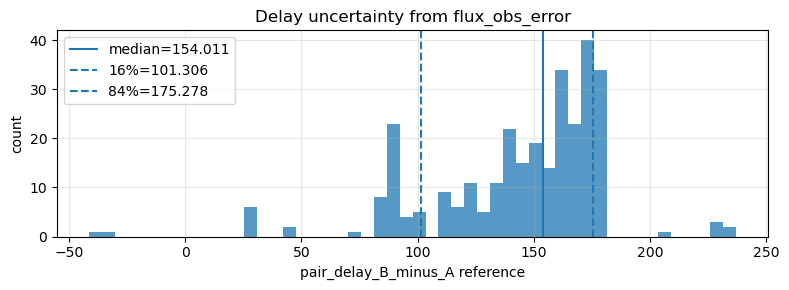

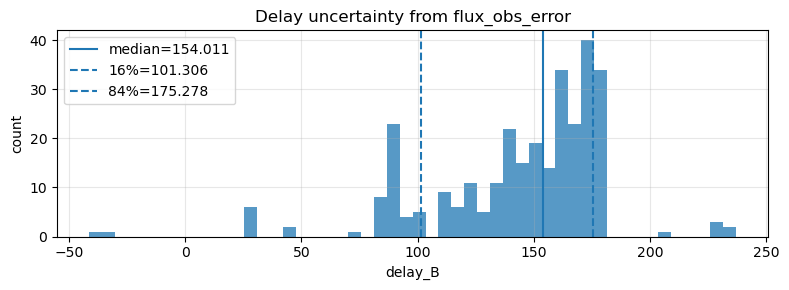

In [190]:
plot_fluxobs_error_mcmc_uncertainty(mcmc, bins=50)